<a href="https://colab.research.google.com/github/hamnaaziz81-prog/Thesis/blob/main/hospital-specialty-transition-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# NOTE:
# The hospital dataset used in this thesis is confidential and is not included
# in this repository. Therefore, the notebook will not run end-to-end without
# access to the private dataset. The code is provided to document the
# preprocessing, transition extraction, probability calculation, and
# visualisation steps used in the thesis.

In [ ]:
file_path = "PRIVATE_DATASET_PATH.csv"
df = pd.read_csv(file_path, sep=";")

In [ ]:

#  Import libraries
import pandas as pd
import numpy as np
# Import plotting library
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Circle
from matplotlib.path import Path

In [ ]:

df = pd.read_csv(file_path, sep=";")

df.head()

,UtenteKey,EpisodioKey,IDADE,Sexo,ProvenienciaExterior,ProvenienciaRecemNascido,ProvenienciaTribunalMedicinaLegal,ProvenienciaServicoInternamento,ProvenienciaBloco,ProvenienciaUrgencia,...,RAD_ESTRUTURAS DENTO-ALVEOLARES,RAD_PSIQUIATRIA,RAD_CIRURGIA MAXILO FACIAL,RAD_OTORRINO,RAD_MEDICINA REPRODUCAO,RAD_ORTOPEDIA,RAD_UROLOGIA,RAD_GINECOLOGIA,RAD_DERMATOLOGIA,RAD_DESENVOLVIMENTO
0,1033035,5023971,97,Feminino,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2008896,5023972,16,Masculino,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1758147,5023973,3,Masculino,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,880347,5023974,79,Feminino,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2009024,5023975,85,Feminino,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df.columns = df.columns.str.strip().str.lower()

df.columns

Index(['utentekey', 'episodiokey', 'idade', 'sexo', 'provenienciaexterior',
       'provenienciarecemnascido', 'provenienciatribunalmedicinalegal',
       'provenienciaservicointernamento', 'provenienciabloco',
       'provenienciaurgencia',
       ...
       'rad_estruturas dento-alveolares', 'rad_psiquiatria',
       'rad_cirurgia maxilo facial', 'rad_otorrino', 'rad_medicina reproducao',
       'rad_ortopedia', 'rad_urologia', 'rad_ginecologia', 'rad_dermatologia',
       'rad_desenvolvimento'],
      dtype='object', length=125)

Rows used: 841548
Number of first assigned specialties: 32
Number of diagnosis/symptom-related columns found: 38
['provenienciaurgencia', 'causaoutros', 'causaqueimadura', 'causaviaverdeavc', 'causaintoxicacao', 'causaqueda', 'causadoenca', 'causaviaverdeeam', 'quedaapostriagem', 'tempoesperatriagemmin', 'urgenciacortriagem', 'urgenciatipo', 'diagnosticodoencasinfeciosas', 'diagnosticodoencasneoplasias', 'diagnosticodoencasendocrinasnutricionaisimunes', 'diagnosticodoencasdosangueedosorgaosproduzemsangue', 'diagnosticodoencasmentais', 'diagnosticodoencassistemacirculatório', 'diagnosticodoencassistemarespiratorio', 'diagnosticodoencassistemadigestivo', 'diagnosticodoencassistemagenitourinario', 'diagnosticoanomaliascongenitas', 'diagnosticocondicoesoriginadasperiodoperinatal', 'diagnosticosintomasgerais', 'diagnosticosintomassistemanerovosoemusculoesqueletico', 'diagnosticosintomaspele', 'diagnosticosintomasmetabolicos', 'diagnosticosintomascabecapescoco', 'diagnosticosintomascardiovas

,condition_group,total_records,top_1_department,top_1_count,top_1_percentage,top_2_department,top_2_count,top_2_percentage,top_3_department,top_3_count,top_3_percentage
0,tempoesperatriagemmin,839863,PEDIATRIA,182549,0.217356,MEDICINA INTERNA,163309,0.194447,MULTIDISCIPLINAR,111781,0.133094
1,causadoenca,622314,PEDIATRIA,156742,0.251870,MEDICINA INTERNA,153987,0.247443,MULTIDISCIPLINAR,104637,0.168142
2,urgenciatipo = Não Atribuído,555412,MEDICINA INTERNA,133175,0.239777,MULTIDISCIPLINAR,105078,0.189189,CIRURGIA GERAL,78412,0.141178
3,urgenciacortriagem = Amarelo,459286,PEDIATRIA,83727,0.182298,MEDICINA INTERNA,78633,0.171207,MULTIDISCIPLINAR,76602,0.166785
4,urgenciacortriagem = Verde,210781,PEDIATRIA,72824,0.345496,MULTIDISCIPLINAR,31146,0.147765,OBSTETRÍCIA,26077,0.123716
5,diagnosticosintomasgerais,161825,CIRURGIA GERAL,54451,0.336481,MEDICINA INTERNA,46628,0.288138,MULTIDISCIPLINAR,29672,0.183359
6,urgenciacortriagem = Laranja,130018,MEDICINA INTERNA,55937,0.430225,PEDIATRIA,21904,0.168469,CIRURGIA GERAL,13718,0.105508
7,urgenciatipo = URGENCIA SIMPLES,110911,PEDIATRIA,101545,0.915554,CIRURGIA PEDIÁTRICA,7682,0.069263,PSIQUIATRIA DA INFÂNCIA E ADOLESCÊNCIA,1458,0.013146
8,diagnosticodoencassistemarespiratorio,84535,PEDIATRIA,43303,0.512249,MEDICINA INTERNA,24889,0.294422,MULTIDISCIPLINAR,10810,0.127876
9,urgenciatipo = URGENCIA COM EXAMES,72843,PEDIATRIA,70048,0.961630,CIRURGIA PEDIÁTRICA,2443,0.033538,OBSTETRÍCIA,115,0.001579


Saved: condition_to_initial_department.csv


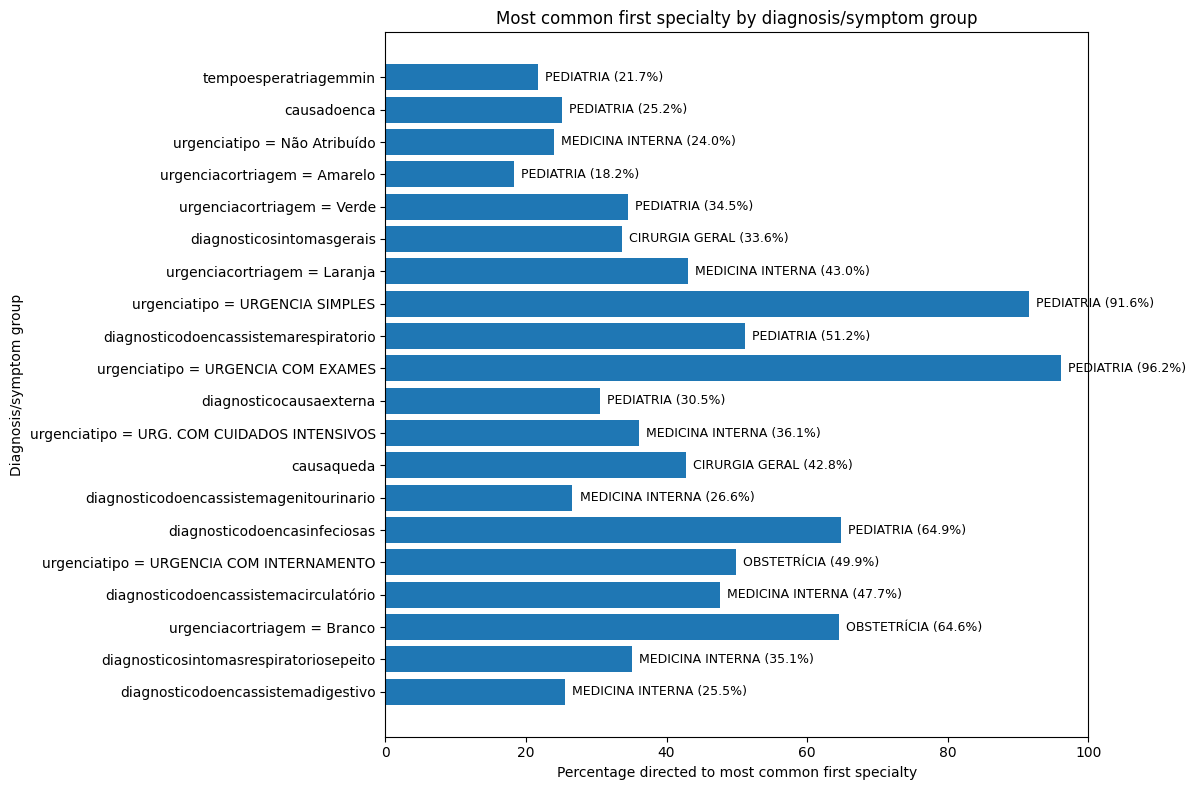

Saved: condition_to_initial_department_top1.png


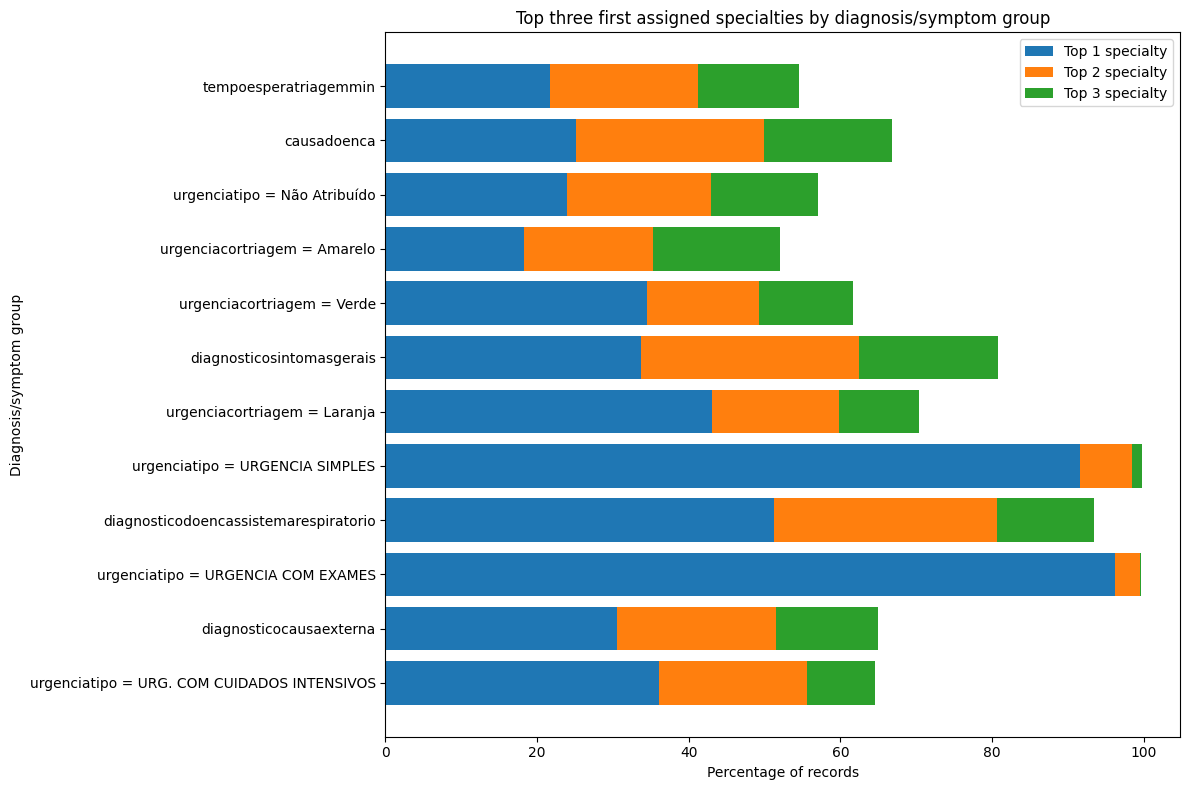

Saved: condition_to_initial_department_top3.png


,condition_group,total_records,top_1_department,top_1_count,top_1_percentage,top_2_department,top_2_count,top_2_percentage,top_3_department,top_3_count,top_3_percentage
0,tempoesperatriagemmin,839863,PEDIATRIA,182549,21.7,MEDICINA INTERNA,163309,19.4,MULTIDISCIPLINAR,111781,13.3
1,causadoenca,622314,PEDIATRIA,156742,25.2,MEDICINA INTERNA,153987,24.7,MULTIDISCIPLINAR,104637,16.8
2,urgenciatipo = Não Atribuído,555412,MEDICINA INTERNA,133175,24.0,MULTIDISCIPLINAR,105078,18.9,CIRURGIA GERAL,78412,14.1
3,urgenciacortriagem = Amarelo,459286,PEDIATRIA,83727,18.2,MEDICINA INTERNA,78633,17.1,MULTIDISCIPLINAR,76602,16.7
4,urgenciacortriagem = Verde,210781,PEDIATRIA,72824,34.5,MULTIDISCIPLINAR,31146,14.8,OBSTETRÍCIA,26077,12.4
5,diagnosticosintomasgerais,161825,CIRURGIA GERAL,54451,33.6,MEDICINA INTERNA,46628,28.8,MULTIDISCIPLINAR,29672,18.3
6,urgenciacortriagem = Laranja,130018,MEDICINA INTERNA,55937,43.0,PEDIATRIA,21904,16.8,CIRURGIA GERAL,13718,10.6
7,urgenciatipo = URGENCIA SIMPLES,110911,PEDIATRIA,101545,91.6,CIRURGIA PEDIÁTRICA,7682,6.9,PSIQUIATRIA DA INFÂNCIA E ADOLESCÊNCIA,1458,1.3
8,diagnosticodoencassistemarespiratorio,84535,PEDIATRIA,43303,51.2,MEDICINA INTERNA,24889,29.4,MULTIDISCIPLINAR,10810,12.8
9,urgenciatipo = URGENCIA COM EXAMES,72843,PEDIATRIA,70048,96.2,CIRURGIA PEDIÁTRICA,2443,3.4,OBSTETRÍCIA,115,0.2


In [ ]:
# ==========================================
# Initial specialty direction by diagnosis/symptom groups
# Run after df is loaded and column names are cleaned
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Target column: first assigned specialty
# ==========================================

target_col = "novaespecialidadedescricao"

if target_col not in df.columns:
    possible_targets = [
        c for c in df.columns
        if "especialidade" in c or "specialty" in c or "department" in c
    ]
    print("Target column not found.")
    print("Possible target columns:", possible_targets)
    raise ValueError("Please check the target column name.")

initial_df = df.copy()
initial_df = initial_df[initial_df[target_col].notna()].copy()

print("Rows used:", initial_df.shape[0])
print("Number of first assigned specialties:", initial_df[target_col].nunique())


# ==========================================
# 2. Find diagnosis/symptom-related columns
# ==========================================

diagnosis_symptom_keywords = [
    "diag", "diagnost", "diagnosis", "cid", "icd",
    "sintoma", "symptom", "queixa", "complaint",
    "causa", "cause", "dor", "pain", "febre", "fever",
    "tosse", "cough", "dispneia", "dyspnea",
    "triagem", "urgencia", "urgency"
]

exclude_keywords = [
    "id", "date", "data", "hora", "time",
    "from_state", "to_state", "count", "probability"
]

condition_cols = []

for col in initial_df.columns:
    col_lower = col.lower()

    if col == target_col:
        continue

    if any(ex in col_lower for ex in exclude_keywords):
        continue

    if any(k in col_lower for k in diagnosis_symptom_keywords):
        condition_cols.append(col)

print("Number of diagnosis/symptom-related columns found:", len(condition_cols))
print(condition_cols[:50])


# ==========================================
# 3. Build condition group → first specialty table
# ==========================================

min_group_size = 200      # change to 100 if you want more small groups
top_n_conditions = 20     # number of groups to show in graph/table

condition_results = []

for col in condition_cols:
    series = initial_df[col]

    # Case A: numeric / boolean indicator columns
    if pd.api.types.is_numeric_dtype(series) or pd.api.types.is_bool_dtype(series):
        mask = series.fillna(0) > 0

        total = int(mask.sum())

        if total >= min_group_size:
            specialty_counts = (
                initial_df.loc[mask, target_col]
                .value_counts()
                .head(3)
            )

            row = {
                "condition_group": col,
                "total_records": total
            }

            for i in range(3):
                if i < len(specialty_counts):
                    dept = specialty_counts.index[i]
                    count = int(specialty_counts.iloc[i])
                    perc = count / total

                    row[f"top_{i+1}_department"] = dept
                    row[f"top_{i+1}_count"] = count
                    row[f"top_{i+1}_percentage"] = perc
                else:
                    row[f"top_{i+1}_department"] = None
                    row[f"top_{i+1}_count"] = 0
                    row[f"top_{i+1}_percentage"] = 0

            condition_results.append(row)

    # Case B: categorical columns with limited categories
    else:
        nunique = series.nunique(dropna=True)

        if 2 <= nunique <= 25:
            for value in series.dropna().unique():
                mask = series == value
                total = int(mask.sum())

                if total >= min_group_size:
                    specialty_counts = (
                        initial_df.loc[mask, target_col]
                        .value_counts()
                        .head(3)
                    )

                    row = {
                        "condition_group": f"{col} = {value}",
                        "total_records": total
                    }

                    for i in range(3):
                        if i < len(specialty_counts):
                            dept = specialty_counts.index[i]
                            count = int(specialty_counts.iloc[i])
                            perc = count / total

                            row[f"top_{i+1}_department"] = dept
                            row[f"top_{i+1}_count"] = count
                            row[f"top_{i+1}_percentage"] = perc
                        else:
                            row[f"top_{i+1}_department"] = None
                            row[f"top_{i+1}_count"] = 0
                            row[f"top_{i+1}_percentage"] = 0

                    condition_results.append(row)


condition_to_department = pd.DataFrame(condition_results)

if condition_to_department.empty:
    print("No diagnosis/symptom groups found with enough records.")
    print("Try reducing min_group_size or check condition_cols.")
else:
    condition_to_department = condition_to_department.sort_values(
        by="total_records",
        ascending=False
    ).reset_index(drop=True)

    print("Condition-to-department table created.")
    display(condition_to_department.head(top_n_conditions))


# ==========================================
# 4. Save table for thesis/reference
# ==========================================

condition_to_department.to_csv(
    "condition_to_initial_department.csv",
    index=False
)

print("Saved: condition_to_initial_department.csv")


# ==========================================
# 5. Graph 1: Top department percentage by condition group
# ==========================================

plot_df = condition_to_department.head(top_n_conditions).copy()

plot_df["top_1_percentage_display"] = plot_df["top_1_percentage"] * 100

plt.figure(figsize=(12, 8))

bars = plt.barh(
    plot_df["condition_group"],
    plot_df["top_1_percentage_display"]
)

plt.gca().invert_yaxis()

plt.xlabel("Percentage directed to most common first specialty")
plt.ylabel("Diagnosis/symptom group")
plt.title("Most common first specialty by diagnosis/symptom group")

for i, row in plot_df.iterrows():
    label = f"{row['top_1_department']} ({row['top_1_percentage_display']:.1f}%)"
    plt.text(
        row["top_1_percentage_display"] + 1,
        i,
        label,
        va="center",
        fontsize=9
    )

plt.xlim(0, min(100, plot_df["top_1_percentage_display"].max() + 25))
plt.tight_layout()

plt.savefig(
    "condition_to_initial_department_top1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: condition_to_initial_department_top1.png")


# ==========================================
# 6. Graph 2: Top 3 first specialties by condition group
# ==========================================

plot_df2 = condition_to_department.head(12).copy()

top1 = plot_df2["top_1_percentage"] * 100
top2 = plot_df2["top_2_percentage"] * 100
top3 = plot_df2["top_3_percentage"] * 100

plt.figure(figsize=(12, 8))

plt.barh(
    plot_df2["condition_group"],
    top1,
    label="Top 1 specialty"
)

plt.barh(
    plot_df2["condition_group"],
    top2,
    left=top1,
    label="Top 2 specialty"
)

plt.barh(
    plot_df2["condition_group"],
    top3,
    left=top1 + top2,
    label="Top 3 specialty"
)

plt.gca().invert_yaxis()

plt.xlabel("Percentage of records")
plt.ylabel("Diagnosis/symptom group")
plt.title("Top three first assigned specialties by diagnosis/symptom group")
plt.legend()

plt.tight_layout()

plt.savefig(
    "condition_to_initial_department_top3.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: condition_to_initial_department_top3.png")


# ==========================================
# 7. Create thesis-friendly rounded table
# ==========================================

thesis_condition_table = condition_to_department.head(15).copy()

percentage_cols = [
    "top_1_percentage",
    "top_2_percentage",
    "top_3_percentage"
]

for col in percentage_cols:
    thesis_condition_table[col] = (thesis_condition_table[col] * 100).round(1)

display(thesis_condition_table)

Diagnosis columns found:
['diagnosticodoencasinfeciosas', 'diagnosticodoencasneoplasias', 'diagnosticodoencasendocrinasnutricionaisimunes', 'diagnosticodoencasdosangueedosorgaosproduzemsangue', 'diagnosticodoencasmentais', 'diagnosticodoencassistemanervosoeorgaossentidos', 'diagnosticodoencassistemacirculatório', 'diagnosticodoencassistemarespiratorio', 'diagnosticodoencassistemadigestivo', 'diagnosticodoencassistemagenitourinario', 'diagnosticocomplicacoesgravidezpartopuerperio', 'diagnosticodoencaspeleetecidosubcutaneo', 'diagnosticodoencassistemamusculoesqueleticoetecidoconjuntivo', 'diagnosticoanomaliascongenitas', 'diagnosticocondicoesoriginadasperiodoperinatal', 'diagnosticosintomasgerais', 'diagnosticosintomassistemanerovosoemusculoesqueletico', 'diagnosticosintomaspele', 'diagnosticosintomasmetabolicos', 'diagnosticosintomascabecapescoco', 'diagnosticosintomascardiovasculares', 'diagnosticosintomasrespiratoriosepeito', 'diagnosticosintomasdigestivos', 'diagnosticosintomasurinár

,diagnosis_group,total_records,most_common_first_specialty,count,percentage
0,diagnosticosintomasgerais,161825,CIRURGIA GERAL,54451,33.648077
1,diagnosticodoencassistemanervosoeorgaossentidos,88720,OFTALMOLOGIA,39136,44.111812
2,diagnosticodoencassistemarespiratorio,84535,PEDIATRIA,43303,51.224936
3,diagnosticocausaexterna,71010,PEDIATRIA,21648,30.485847
4,diagnosticodoencassistemamusculoesqueleticoete...,70798,ORTOPEDIA,34972,49.396876
5,diagnosticodoencassistemagenitourinario,42706,MEDICINA INTERNA,11367,26.616869
6,diagnosticodoencasinfeciosas,38920,PEDIATRIA,25244,64.861254
7,diagnosticodoencassistemacirculatório,28919,MEDICINA INTERNA,13785,47.667623
8,diagnosticosintomasrespiratoriosepeito,25218,MEDICINA INTERNA,8848,35.086050
9,diagnosticodoencassistemadigestivo,23724,MEDICINA INTERNA,6047,25.488956


Saved: diagnosis_to_initial_department.csv


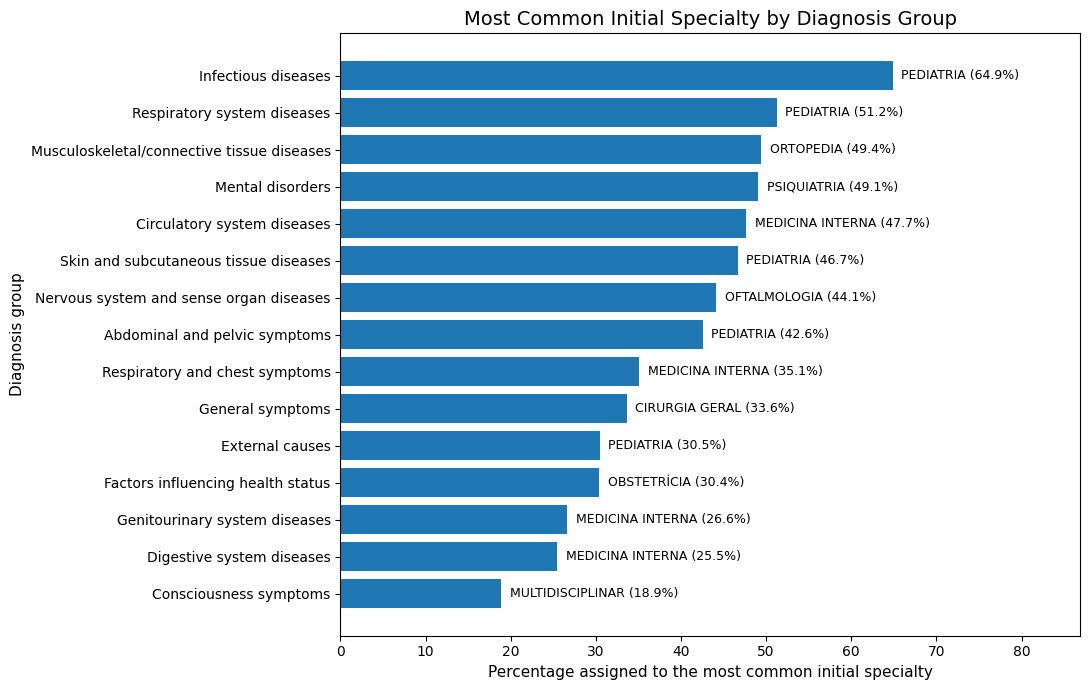

Saved: diagnosis_to_initial_specialty_clean.png


In [ ]:
# ==========================================
# Diagnosis groups -> most common initial assigned specialty
# Clean thesis graph
# Run after df is loaded and column names are cleaned
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Target column: first assigned specialty
# ==========================================

target_col = "novaespecialidadedescricao"

if target_col not in df.columns:
    possible_targets = [
        c for c in df.columns
        if "especialidade" in c or "specialty" in c or "department" in c
    ]
    print("Target column not found.")
    print("Possible target columns:", possible_targets)
    raise ValueError("Please check the target column name.")

initial_df = df[df[target_col].notna()].copy()

# ==========================================
# 2. Select diagnosis columns only
# ==========================================

diagnosis_cols = [
    col for col in initial_df.columns
    if (
        col.startswith("diagnostico")
        and col != target_col
        and initial_df[col].nunique(dropna=True) <= 5
    )
]

print("Diagnosis columns found:")
print(diagnosis_cols)

# ==========================================
# 3. Build diagnosis group -> most common first specialty table
# ==========================================

min_group_size = 200

results = []

for col in diagnosis_cols:
    series = initial_df[col]

    # Indicator columns: positive / 1 / True means patient belongs to that diagnosis group
    if pd.api.types.is_numeric_dtype(series) or pd.api.types.is_bool_dtype(series):
        mask = series.fillna(0) > 0
    else:
        positive_values = ["1", "true", "yes", "sim", "s", "y"]
        mask = series.astype(str).str.lower().isin(positive_values)

    total = int(mask.sum())

    if total >= min_group_size:
        specialty_counts = initial_df.loc[mask, target_col].value_counts()

        top_specialty = specialty_counts.index[0]
        top_count = int(specialty_counts.iloc[0])
        top_percentage = top_count / total * 100

        results.append({
            "diagnosis_group": col,
            "total_records": total,
            "most_common_first_specialty": top_specialty,
            "count": top_count,
            "percentage": top_percentage
        })

diagnosis_to_department = pd.DataFrame(results)

diagnosis_to_department = diagnosis_to_department.sort_values(
    by="total_records",
    ascending=False
).reset_index(drop=True)

display(diagnosis_to_department)

diagnosis_to_department.to_csv(
    "diagnosis_to_initial_department.csv",
    index=False
)

print("Saved: diagnosis_to_initial_department.csv")

# ==========================================
# 4. Clean diagnosis labels, keep department names unchanged
# ==========================================

diagnosis_label_map = {
    "diagnosticosintomasgerais": "General symptoms",
    "diagnosticodoencassistemanervosoeorgaossentidos": "Nervous system and sense organ diseases",
    "diagnosticodoencassistemarespiratorio": "Respiratory system diseases",
    "diagnosticocausaexterna": "External causes",
    "diagnosticodoencassistemamusculoesqueleticoetecidoconjuntivo": "Musculoskeletal/connective tissue diseases",
    "diagnosticodoencassistemagenitourinario": "Genitourinary system diseases",
    "diagnosticodoencasinfeciosas": "Infectious diseases",
    "diagnosticodoencassistemacirculatório": "Circulatory system diseases",
    "diagnosticodoencassistemacirculatorio": "Circulatory system diseases",
    "diagnosticosintomasrespiratoriosepeito": "Respiratory and chest symptoms",
    "diagnosticodoencassistemadigestivo": "Digestive system diseases",
    "diagnosticodoencasmentais": "Mental disorders",
    "diagnosticofatoresinfluenciamestadosaude": "Factors influencing health status",
    "diagnosticodoencaspeleetecidosubcutaneo": "Skin and subcutaneous tissue diseases",
    "diagnosticosintomasabdomenepelvis": "Abdominal and pelvic symptoms",
    "diagnosticosintomasconsciencia": "Consciousness symptoms",
    "diagnosticosintomasdigestivos": "Digestive symptoms",
    "diagnosticocomplicacoesgravidezpartopuerperio": "Pregnancy, childbirth and puerperium",
    "diagnosticodoencasneoplasias": "Neoplasms",
    "diagnosticosintomasurinários": "Urinary symptoms",
    "diagnosticosintomasurinarios": "Urinary symptoms",
    "diagnosticodoencasendocrinasnutricionaisimunes": "Endocrine, nutritional and immune diseases",
    "diagnosticodoencasdosangueedosorgaosproduzemsangue": "Blood and blood-forming organ diseases",
    "diagnosticosintomascardiovasculares": "Cardiovascular symptoms",
    "diagnosticosintomaspele": "Skin symptoms",
    "diagnosticosintomassistemanerovosoemusculoesqueletico": "Nervous and musculoskeletal symptoms",
    "diagnosticocondicoesoriginadasperiodoperinatal": "Perinatal conditions",
    "diagnosticoachadosnaoespecificos": "Non-specific findings",
    "diagnosticoanomaliascongenitas": "Congenital anomalies",
    "diagnosticosintomascabecapescoco": "Head and neck symptoms"
}

plot_df = diagnosis_to_department.copy()

plot_df["diagnosis_label"] = plot_df["diagnosis_group"].map(diagnosis_label_map)
plot_df["diagnosis_label"] = plot_df["diagnosis_label"].fillna(plot_df["diagnosis_group"])

# Keep department names exactly as original from the dataset
plot_df["specialty_label"] = plot_df["most_common_first_specialty"]

# Use top 15 groups to avoid overcrowding
plot_df = plot_df.head(15).copy()

# Sort by percentage for readable plot
plot_df = plot_df.sort_values("percentage", ascending=True)

# ==========================================
# 5. Plot clean thesis graph
# ==========================================

plt.figure(figsize=(11, 7))

plt.barh(
    plot_df["diagnosis_label"],
    plot_df["percentage"]
)

plt.xlabel("Percentage assigned to the most common initial specialty", fontsize=11)
plt.ylabel("Diagnosis group", fontsize=11)
plt.title("Most Common Initial Specialty by Diagnosis Group", fontsize=14)

for i, row in enumerate(plot_df.itertuples()):
    label = f"{row.specialty_label} ({row.percentage:.1f}%)"
    plt.text(
        row.percentage + 1,
        i,
        label,
        va="center",
        fontsize=9
    )

plt.xlim(0, min(100, plot_df["percentage"].max() + 22))
plt.tight_layout()

plt.savefig(
    "diagnosis_to_initial_specialty_clean.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: diagnosis_to_initial_specialty_clean.png")

In [ ]:
[c for c in diagnosis_to_department["diagnosis_group"] if "infecc" in c.lower()]
[c for c in diagnosis_to_department["diagnosis_group"] if "nerv" in c.lower()]

['diagnosticodoencassistemanervosoeorgaossentidos']

In [ ]:
diagnosis_to_department["diagnosis_group"].tolist()

['diagnosticosintomasgerais',
 'diagnosticodoencassistemanervosoeorgaossentidos',
 'diagnosticodoencassistemarespiratorio',
 'diagnosticocausaexterna',
 'diagnosticodoencassistemamusculoesqueleticoetecidoconjuntivo',
 'diagnosticodoencassistemagenitourinario',
 'diagnosticodoencasinfeciosas',
 'diagnosticodoencassistemacirculatório',
 'diagnosticosintomasrespiratoriosepeito',
 'diagnosticodoencassistemadigestivo',
 'diagnosticodoencasmentais',
 'diagnosticofatoresinfluenciamestadosaude',
 'diagnosticodoencaspeleetecidosubcutaneo',
 'diagnosticosintomasabdomenepelvis',
 'diagnosticosintomasconsciencia',
 'diagnosticosintomasdigestivos',
 'diagnosticocomplicacoesgravidezpartopuerperio',
 'diagnosticodoencasneoplasias',
 'diagnosticosintomasurinários',
 'diagnosticodoencasendocrinasnutricionaisimunes',
 'diagnosticodoencasdosangueedosorgaosproduzemsangue',
 'diagnosticosintomascardiovasculares',
 'diagnosticosintomaspele',
 'diagnosticosintomassistemanerovosoemusculoesqueletico',
 'diagno

# **Set important columns**

In [ ]:
# ==========================================
# 1. Define important base columns
# ==========================================

patient_id_col = "utentekey"
time_col = "dataadmissao"
unit_col = "novaespecialidadedescricao"

age_col = "idade"
gender_col = "sexo"

In [ ]:
# ==========================================
# 2. Automatically select clinically important columns
# ==========================================

important_keywords = [
    # urgency / triage
    "urgencia", "triagem", "manchester",

    # diagnosis
    "diagnostico", "diag",

    # symptoms / causes
    "sintoma", "causa", "queixa",

    # exams / lab / radiology
    "exame", "lab", "analise", "rx", "rad",

    # provenance / origin
    "proveniencia", "origem",

    # demographics
    "idade", "sexo"
]

selected_feature_cols = []

for col in df.columns:
    col_lower = col.lower()
    if any(keyword in col_lower for keyword in important_keywords):
        selected_feature_cols.append(col)

# Always include current specialty as a predictor
if unit_col not in selected_feature_cols:
    selected_feature_cols.append(unit_col)

# Remove duplicates
selected_feature_cols = list(dict.fromkeys(selected_feature_cols))

print("Number of selected feature columns:", len(selected_feature_cols))
selected_feature_cols

Number of selected feature columns: 108


['idade',
 'sexo',
 'provenienciaexterior',
 'provenienciarecemnascido',
 'provenienciatribunalmedicinalegal',
 'provenienciaservicointernamento',
 'provenienciabloco',
 'provenienciaurgencia',
 'provenienciaunidadedialise',
 'provenienciahospital',
 'provenienciasaude24',
 'provenienciainem',
 'provenienciaid_ajustado',
 'causaoutros',
 'causaacidentenviacao',
 'causaqueimadura',
 'causaviaverdeavc',
 'causaintoxicacao',
 'causaqueda',
 'causagravidasparturientes',
 'causadoenca',
 'causaviaverdeeam',
 'causaacidenteviacao',
 'especialidadeprimeiraobservacaokey',
 'novaespecialidadedescricao',
 'especialidadepsiquiatria',
 'especialidadecardiologia',
 'especialidadepneumologia',
 'especialidadecirurgia',
 'especialidadeginecologiaobstetricia',
 'especialidadeortopedia',
 'especialidadeneurologia',
 'especialidadegastroenterologia',
 'especialidadeotorrino',
 'especialidademultidisciplinar',
 'especialidadeoftalmologia',
 'especialidademedicinainterna',
 'especialidadeurologia',
 'espe

In [ ]:
# ==========================================
# 3. Remove leakage / outcome columns
# ==========================================

leakage_keywords = [
    "dataalta",
    "dataobito",
    "obito",
    "readmissao",
    "diasreadmissao",
    "los",
    "needs_review",
    "severity",
    "suggested_action"
]

clean_feature_cols = []

for col in selected_feature_cols:
    col_lower = col.lower()

    if any(keyword in col_lower for keyword in leakage_keywords):
        continue

    if col in [patient_id_col, time_col]:
        continue

    clean_feature_cols.append(col)

print("Number of clean feature columns:", len(clean_feature_cols))
clean_feature_cols

Number of clean feature columns: 108


['idade',
 'sexo',
 'provenienciaexterior',
 'provenienciarecemnascido',
 'provenienciatribunalmedicinalegal',
 'provenienciaservicointernamento',
 'provenienciabloco',
 'provenienciaurgencia',
 'provenienciaunidadedialise',
 'provenienciahospital',
 'provenienciasaude24',
 'provenienciainem',
 'provenienciaid_ajustado',
 'causaoutros',
 'causaacidentenviacao',
 'causaqueimadura',
 'causaviaverdeavc',
 'causaintoxicacao',
 'causaqueda',
 'causagravidasparturientes',
 'causadoenca',
 'causaviaverdeeam',
 'causaacidenteviacao',
 'especialidadeprimeiraobservacaokey',
 'novaespecialidadedescricao',
 'especialidadepsiquiatria',
 'especialidadecardiologia',
 'especialidadepneumologia',
 'especialidadecirurgia',
 'especialidadeginecologiaobstetricia',
 'especialidadeortopedia',
 'especialidadeneurologia',
 'especialidadegastroenterologia',
 'especialidadeotorrino',
 'especialidademultidisciplinar',
 'especialidadeoftalmologia',
 'especialidademedicinainterna',
 'especialidadeurologia',
 'espe

In [ ]:
# ==========================================
# 4. Create transition-level prediction dataset
# ==========================================

model_base = df.copy()

# Standardize key columns
model_base[unit_col] = model_base[unit_col].astype(str).str.strip().str.lower()
model_base[gender_col] = model_base[gender_col].astype(str).str.strip().str.lower()
model_base[age_col] = pd.to_numeric(model_base[age_col], errors="coerce")

# Sort each patient's records by time
model_base = model_base.sort_values([patient_id_col, time_col])

# Current specialty
model_base["from_state"] = model_base[unit_col]

# Next specialty = target
model_base["to_state"] = (
    model_base
    .groupby(patient_id_col)[unit_col]
    .shift(-1)
)

# Keep only rows where next specialty exists
transition_model_df = model_base.dropna(subset=["to_state"]).copy()

# Remove invalid states
transition_model_df = transition_model_df[
    (transition_model_df["from_state"].astype(str).str.lower() != "nan") &
    (transition_model_df["to_state"].astype(str).str.lower() != "nan")
].copy()

print("Transition-level rows:", transition_model_df.shape[0])
print("Number of features:", len(clean_feature_cols))
print("Number of target classes:", transition_model_df["to_state"].nunique())

Transition-level rows: 476587
Number of features: 108
Number of target classes: 30


In [ ]:
# ==========================================
# 5. Prepare baseline and clinical feature sets
# ==========================================

target_col = "to_state"

baseline_features = ["from_state"]

# Replace original unit_col with from_state, because from_state is clearer
clinical_features = []

for col in clean_feature_cols:
    if col == unit_col:
        continue
    clinical_features.append(col)

clinical_features = ["from_state"] + clinical_features

print("Baseline features:", baseline_features)
print("Clinical model features:", len(clinical_features))
clinical_features

Baseline features: ['from_state']
Clinical model features: 108


['from_state',
 'idade',
 'sexo',
 'provenienciaexterior',
 'provenienciarecemnascido',
 'provenienciatribunalmedicinalegal',
 'provenienciaservicointernamento',
 'provenienciabloco',
 'provenienciaurgencia',
 'provenienciaunidadedialise',
 'provenienciahospital',
 'provenienciasaude24',
 'provenienciainem',
 'provenienciaid_ajustado',
 'causaoutros',
 'causaacidentenviacao',
 'causaqueimadura',
 'causaviaverdeavc',
 'causaintoxicacao',
 'causaqueda',
 'causagravidasparturientes',
 'causadoenca',
 'causaviaverdeeam',
 'causaacidenteviacao',
 'especialidadeprimeiraobservacaokey',
 'especialidadepsiquiatria',
 'especialidadecardiologia',
 'especialidadepneumologia',
 'especialidadecirurgia',
 'especialidadeginecologiaobstetricia',
 'especialidadeortopedia',
 'especialidadeneurologia',
 'especialidadegastroenterologia',
 'especialidadeotorrino',
 'especialidademultidisciplinar',
 'especialidadeoftalmologia',
 'especialidademedicinainterna',
 'especialidadeurologia',
 'especialidademedicin

In [ ]:
# ==========================================
# Create filtered transition table for fuzzy graphs
# ==========================================

target_col = "to_state"

next_class_counts = transition_model_df[target_col].value_counts()

min_class_count = 20

valid_next_classes = next_class_counts[
    next_class_counts >= min_class_count
].index

transition_model_df_filtered = transition_model_df[
    transition_model_df[target_col].isin(valid_next_classes)
].copy()

print("Rows after filtering:", transition_model_df_filtered.shape[0])
print("Target classes after filtering:", transition_model_df_filtered[target_col].nunique())
print("Smallest remaining class count:", transition_model_df_filtered[target_col].value_counts().min())

Rows after filtering: 476559
Target classes after filtering: 26
Smallest remaining class count: 26


In [ ]:
# ==========================================
# Create filtered transition table for fuzzy graphs
# ==========================================

target_col = "to_state"

next_class_counts = transition_model_df[target_col].value_counts()

min_class_count = 20

valid_next_classes = next_class_counts[
    next_class_counts >= min_class_count
].index

transition_model_df_filtered = transition_model_df[
    transition_model_df[target_col].isin(valid_next_classes)
].copy()

print("Rows after filtering:", transition_model_df_filtered.shape[0])
print("Target classes after filtering:", transition_model_df_filtered[target_col].nunique())
print("Smallest remaining class count:", transition_model_df_filtered[target_col].value_counts().min())

Rows after filtering: 476559
Target classes after filtering: 26
Smallest remaining class count: 26


In [ ]:
# ==========================================
# Check selected clinical feature columns
# ==========================================

selected_columns_summary = pd.DataFrame({
    "feature_column": clean_feature_cols,
    "dtype": [str(df[col].dtype) for col in clean_feature_cols],
    "missing_percentage": [round(df[col].isna().mean() * 100, 2) for col in clean_feature_cols],
    "unique_values": [df[col].nunique(dropna=True) for col in clean_feature_cols]
})

print("Number of clean selected feature columns:", len(clean_feature_cols))

selected_columns_summary

Number of clean selected feature columns: 108


,feature_column,dtype,missing_percentage,unique_values
0,idade,int64,0.0,111
1,sexo,object,0.0,2
2,provenienciaexterior,int64,0.0,2
3,provenienciarecemnascido,int64,0.0,2
4,provenienciatribunalmedicinalegal,int64,0.0,2
...,...,...,...,...
103,rad_ortopedia,int64,0.0,3
104,rad_urologia,int64,0.0,2
105,rad_ginecologia,int64,0.0,2
106,rad_dermatologia,int64,0.0,1


In [ ]:
# ==========================================
# Check cause/symptom-related columns
# ==========================================

cause_cols = [
    col for col in df.columns
    if col.lower().startswith("causa")
]

symptom_diagnosis_cols = [
    col for col in df.columns
    if "sintoma" in col.lower()
]

print("Cause columns:", len(cause_cols))
print(cause_cols)

print("\nSymptom diagnosis columns:", len(symptom_diagnosis_cols))
print(symptom_diagnosis_cols)

Cause columns: 10
['causaoutros', 'causaacidentenviacao', 'causaqueimadura', 'causaviaverdeavc', 'causaintoxicacao', 'causaqueda', 'causagravidasparturientes', 'causadoenca', 'causaviaverdeeam', 'causaacidenteviacao']

Symptom diagnosis columns: 11
['diagnosticosintomasgerais', 'diagnosticosintomassistemanerovosoemusculoesqueletico', 'diagnosticosintomaspele', 'diagnosticosintomasmetabolicos', 'diagnosticosintomascabecapescoco', 'diagnosticosintomascardiovasculares', 'diagnosticosintomasrespiratoriosepeito', 'diagnosticosintomasdigestivos', 'diagnosticosintomasurinários', 'diagnosticosintomasabdomenepelvis', 'diagnosticosintomasconsciencia']


In [ ]:
# ==========================================
# Explore where patients with each symptom/cause are directed
# ==========================================

routing_target = "novaespecialidadedescricao"

routing_outputs = []

all_symptom_like_cols = cause_cols + symptom_diagnosis_cols

for col in all_symptom_like_cols:
    if df[col].nunique(dropna=True) <= 1:
        continue

    subset = df[df[col] == 1]

    if subset.empty:
        continue

    department_counts = subset[routing_target].value_counts()
    department_proportions = subset[routing_target].value_counts(normalize=True)

    top_departments = (
        pd.DataFrame({
            "department": department_counts.index,
            "count": department_counts.values,
            "proportion": department_proportions.values
        })
        .head(5)
    )

    for _, row in top_departments.iterrows():
        routing_outputs.append({
            "clinical_indicator": col,
            "department": row["department"],
            "count": row["count"],
            "proportion": round(row["proportion"], 4),
            "total_indicator_cases": len(subset)
        })

symptom_routing_df = pd.DataFrame(routing_outputs)

symptom_routing_df.head(50)

,clinical_indicator,department,count,proportion,total_indicator_cases
0,causaoutros,CIRURGIA GERAL,4676,0.2182,21549
1,causaoutros,MEDICINA INTERNA,4035,0.1883,21549
2,causaoutros,ORTOPEDIA,3510,0.1638,21549
3,causaoutros,OFTALMOLOGIA,3306,0.1542,21549
4,causaoutros,MULTIDISCIPLINAR,2414,0.1126,21549
5,causaacidentenviacao,PEDIATRIA,21952,0.3803,57811
6,causaacidentenviacao,ORTOPEDIA,11111,0.1925,57811
7,causaacidentenviacao,OFTALMOLOGIA,8998,0.1559,57811
8,causaacidentenviacao,CIRURGIA GERAL,6923,0.1199,57811
9,causaacidentenviacao,CIRURGIA PEDIÁTRICA,4627,0.0802,57811


In [ ]:
# ==========================================
# Initial Routing Prediction Model
# Early clinical information -> assigned/current specialty
# ==========================================

initial_target = unit_col   # novaespecialidadedescricao

# Use early clinical information only
# Do NOT include current specialty indicators here, because they are too close to the target.
initial_feature_keywords = [
    "idade",
    "sexo",
    "proveniencia",
    "causa",
    "urgencia",
    "triagem",
    "manchester",
    "diagnostico"
]

initial_feature_cols = []

for col in df.columns:
    col_lower = col.lower()
    if any(keyword in col_lower for keyword in initial_feature_keywords):
        initial_feature_cols.append(col)

# Remove target/leakage/future/outcome/data quality columns
remove_from_initial = [
    unit_col,
    "especialidadeprimeiraobservacaokey",
    "admpediatria",
    "especialidadepsiquiatria",
    "especialidadecardiologia",
    "especialidadepneumologia",
    "especialidadecirurgia",
    "especialidadeginecologiaobstetricia",
    "especialidadeortopedia",
    "especialidadeneurologia",
    "especialidadegastroenterologia",
    "especialidadeotorrino",
    "especialidademultidisciplinar",
    "especialidadeoftalmologia",
    "especialidademedicinainterna",
    "especialidadeurologia",
    "especialidademedicinaintensiva",
    "especialidadeoutros",
    "dataalta",
    "dataobito",
    "obito",
    "destinoid",
    "destinodescricao",
    "diasreadmissao",
    "los",
    "data_issue",
    "needs_review",
    "severity",
    "suggested_action",
    "utentekey",
    "episodiokey",
    "dataadmissao",
    "datatriagem",
    "dataatendimento"
]

initial_feature_cols = [
    col for col in initial_feature_cols
    if col not in remove_from_initial
]

print("Initial routing target:", initial_target)
print("Number of initial routing features:", len(initial_feature_cols))

initial_feature_cols

Initial routing target: novaespecialidadedescricao
Number of initial routing features: 60


['idade',
 'sexo',
 'provenienciaexterior',
 'provenienciarecemnascido',
 'provenienciatribunalmedicinalegal',
 'provenienciaservicointernamento',
 'provenienciabloco',
 'provenienciaurgencia',
 'provenienciaunidadedialise',
 'provenienciahospital',
 'provenienciasaude24',
 'provenienciainem',
 'provenienciaid_ajustado',
 'causaoutros',
 'causaacidentenviacao',
 'causaqueimadura',
 'causaviaverdeavc',
 'causaintoxicacao',
 'causaqueda',
 'causagravidasparturientes',
 'causadoenca',
 'causaviaverdeeam',
 'causaacidenteviacao',
 'quedaapostriagem',
 'tempoesperatriagemmin',
 'tempomaximoesperamanchester',
 'urgenciaprioridade',
 'urgenciacortriagem',
 'urgenciatipo',
 'diagnosticodoencasinfeciosas',
 'diagnosticodoencasneoplasias',
 'diagnosticodoencasendocrinasnutricionaisimunes',
 'diagnosticodoencasdosangueedosorgaosproduzemsangue',
 'diagnosticodoencasmentais',
 'diagnosticodoencassistemanervosoeorgaossentidos',
 'diagnosticodoencassistemacirculatório',
 'diagnosticodoencassistemares

In [ ]:
# ==========================================
# Prepare initial routing dataset
# ==========================================

initial_routing_df = df.copy()

# Clean target
initial_routing_df[initial_target] = (
    initial_routing_df[initial_target]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Remove invalid target values
initial_routing_df = initial_routing_df[
    initial_routing_df[initial_target].notna() &
    (initial_routing_df[initial_target].astype(str).str.lower() != "nan")
].copy()

X_initial = initial_routing_df[initial_feature_cols].copy()
y_initial = initial_routing_df[initial_target].copy()

print("Initial routing rows:", X_initial.shape[0])
print("Initial routing features:", X_initial.shape[1])
print("Initial routing target classes:", y_initial.nunique())

Initial routing rows: 841548
Initial routing features: 60
Initial routing target classes: 32


In [ ]:
# ==========================================
# Remove possible timing-leakage column
# ==========================================

if "quedaapostriagem" in initial_feature_cols:
    initial_feature_cols.remove("quedaapostriagem")

X_initial = initial_routing_df[initial_feature_cols].copy()
y_initial = initial_routing_df[initial_target].copy()

print("Initial routing rows:", X_initial.shape[0])
print("Initial routing features:", X_initial.shape[1])
print("Initial routing target classes:", y_initial.nunique())

Initial routing rows: 841548
Initial routing features: 59
Initial routing target classes: 32


In [ ]:
# ==========================================
# Check target class counts
# ==========================================

initial_class_counts = y_initial.value_counts()

print("Number of target classes:", initial_class_counts.shape[0])
print("Smallest class count:", initial_class_counts.min())

initial_class_counts.tail(10)

Number of target classes: 32
Smallest class count: 1


,count
novaespecialidadedescricao,
cirurgia maxilo-facial,315
queimados,302
dermato-venereologia,107
cardiologia pediátrica,100
hematologia clínica,28
cirurgia cardio-torácica,19
doenças oncológicas,19
endocrinologia e nutrição,9
anestesiologia,1


In [ ]:
# ==========================================
# Remove very rare target classes
# ==========================================

min_class_count = 20

valid_classes = initial_class_counts[
    initial_class_counts >= min_class_count
].index

initial_routing_df_filtered = initial_routing_df[
    initial_routing_df[initial_target].isin(valid_classes)
].copy()

X_initial = initial_routing_df_filtered[initial_feature_cols].copy()
y_initial = initial_routing_df_filtered[initial_target].copy()

print("Rows after removing rare classes:", X_initial.shape[0])
print("Features:", X_initial.shape[1])
print("Target classes after filtering:", y_initial.nunique())
print("Smallest remaining class count:", y_initial.value_counts().min())

Rows after removing rare classes: 841499
Features: 59
Target classes after filtering: 27
Smallest remaining class count: 28


In [ ]:
# ==========================================
# Train/test split for initial routing model
# ==========================================

from sklearn.model_selection import train_test_split

Xi_train, Xi_test, yi_train, yi_test = train_test_split(
    X_initial,
    y_initial,
    test_size=0.2,
    random_state=42,
    stratify=y_initial
)

print("Initial routing train shape:", Xi_train.shape)
print("Initial routing test shape:", Xi_test.shape)
print("Train target classes:", yi_train.nunique())
print("Test target classes:", yi_test.nunique())

Initial routing train shape: (673199, 59)
Initial routing test shape: (168300, 59)
Train target classes: 27
Test target classes: 27


In [ ]:
# ==========================================
# Build and train initial routing model
# ==========================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

def build_initial_routing_model(X):
    categorical_cols = X.select_dtypes(include=["object", "bool"]).columns.tolist()
    numeric_cols = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore"))
            ]), categorical_cols),

            ("num", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median"))
            ]), numeric_cols)
        ]
    )

    model = RandomForestClassifier(
        n_estimators=150,
        max_depth=20,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample"
    )

    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    return pipe

initial_routing_model = build_initial_routing_model(Xi_train)

initial_routing_model.fit(Xi_train, yi_train)

print("Initial routing model training complete.")

Initial routing model training complete.


In [ ]:
# ==========================================
# Evaluate initial routing model
# ==========================================

from sklearn.metrics import accuracy_score, top_k_accuracy_score
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd

yi_pred = initial_routing_model.predict(Xi_test)

top1_initial = accuracy_score(yi_test, yi_pred)

label_encoder_initial = LabelEncoder()
label_encoder_initial.fit(yi_train)

yi_test_encoded = label_encoder_initial.transform(yi_test)

proba_initial = initial_routing_model.predict_proba(Xi_test)
model_classes_initial = initial_routing_model.classes_

aligned_proba_initial = np.zeros((len(Xi_test), len(label_encoder_initial.classes_)))

for i, cls in enumerate(model_classes_initial):
    class_index = np.where(label_encoder_initial.classes_ == cls)[0][0]
    aligned_proba_initial[:, class_index] = proba_initial[:, i]

top3_initial = top_k_accuracy_score(
    yi_test_encoded,
    aligned_proba_initial,
    k=3,
    labels=np.arange(len(label_encoder_initial.classes_))
)

top5_initial = top_k_accuracy_score(
    yi_test_encoded,
    aligned_proba_initial,
    k=5,
    labels=np.arange(len(label_encoder_initial.classes_))
)

initial_routing_results = pd.DataFrame([{
    "model": "Initial routing model",
    "target": "current/assigned specialty",
    "features": len(initial_feature_cols),
    "top_1_accuracy": top1_initial,
    "top_3_accuracy": top3_initial,
    "top_5_accuracy": top5_initial
}])

initial_routing_results

,model,target,features,top_1_accuracy,top_3_accuracy,top_5_accuracy
0,Initial routing model,current/assigned specialty,59,0.548081,0.802228,0.909115


In [ ]:
# ==========================================
# Feature importance for initial routing model
# ==========================================

preprocessor_initial = initial_routing_model.named_steps["preprocessor"]
rf_initial = initial_routing_model.named_steps["model"]

initial_feature_names = preprocessor_initial.get_feature_names_out()
initial_importances = rf_initial.feature_importances_

initial_feature_importance_df = pd.DataFrame({
    "feature": initial_feature_names,
    "importance": initial_importances
}).sort_values("importance", ascending=False)

initial_feature_importance_df.head(50)

,feature,importance
25,num__idade,0.111707
53,num__diagnosticodoencasmentais,0.068772
43,num__causagravidasparturientes,0.062655
57,num__diagnosticodoencassistemadigestivo,0.041963
44,num__causadoenca,0.040057
24,cat__urgenciatipo_URGENCIA SIMPLES,0.038336
58,num__diagnosticodoencassistemagenitourinario,0.037120
36,num__provenienciaid_ajustado,0.033756
54,num__diagnosticodoencassistemanervosoeorgaosse...,0.033604
47,num__tempoesperatriagemmin,0.030609


In [ ]:
# ==========================================
# Group initial routing feature importance by clinical theme
# ==========================================

def get_initial_theme(feature_name):
    f = feature_name.lower()

    if "idade" in f:
        return "age"
    if "sexo" in f:
        return "sex"
    if "urgencia" in f or "triagem" in f or "manchester" in f:
        return "urgency_triage"
    if "diagnostico" in f or "diag" in f:
        return "diagnosis_symptoms"
    if "sintoma" in f or "causa" in f or "queixa" in f:
        return "causes_symptoms"
    if "proveniencia" in f or "origem" in f:
        return "origin_provenance"
    return "other"

initial_feature_importance_df["theme"] = (
    initial_feature_importance_df["feature"].apply(get_initial_theme)
)

initial_theme_importance_df = (
    initial_feature_importance_df
    .groupby("theme")["importance"]
    .sum()
    .reset_index()
    .sort_values("importance", ascending=False)
)

initial_theme_importance_df

,theme,importance
2,diagnosis_symptoms,0.358205
5,urgency_triage,0.216257
0,age,0.158593
1,causes_symptoms,0.144314
3,origin_provenance,0.091861
4,sex,0.030771


# **NEXT-SPECIALTY PREDICTION MODEL**

# Adult core graph

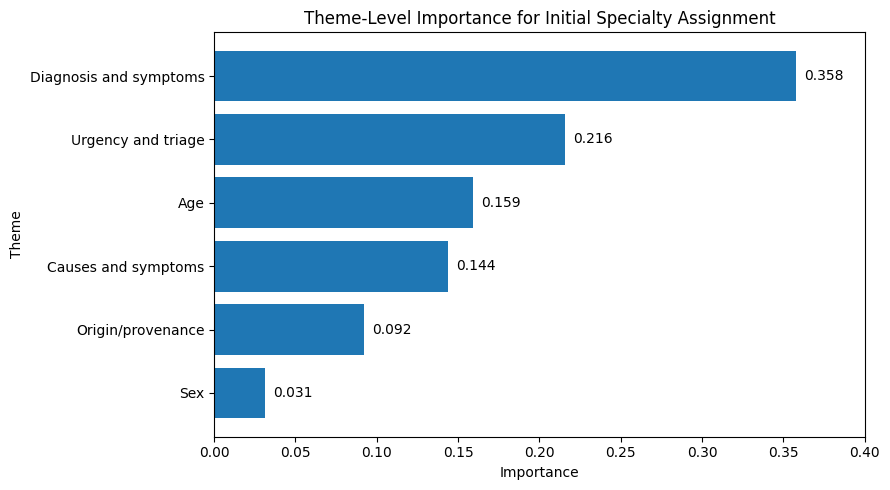

In [ ]:
# ==========================================
# Theme-level importance bar graph
# Initial specialty assignment model
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

# Create the importance table
theme_importance_df = pd.DataFrame({
    "Theme": [
        "Diagnosis and symptoms",
        "Urgency and triage",
        "Age",
        "Causes and symptoms",
        "Origin/provenance",
        "Sex"
    ],
    "Importance": [
        0.358,
        0.216,
        0.159,
        0.144,
        0.092,
        0.031
    ]
})

# Sort so the most important appears at the top
theme_importance_df = theme_importance_df.sort_values(
    "Importance",
    ascending=True
)

# Plot
plt.figure(figsize=(9, 5))

plt.barh(
    theme_importance_df["Theme"],
    theme_importance_df["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Theme")
plt.title("Theme-Level Importance for Initial Specialty Assignment")

# Add values at the end of each bar
for index, value in enumerate(theme_importance_df["Importance"]):
    plt.text(
        value + 0.005,
        index,
        f"{value:.3f}",
        va="center",
        fontsize=10
    )

plt.xlim(0, 0.40)
plt.tight_layout()

plt.savefig(
    "theme_level_importance_initial_assignment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ==========================================
# Create filtered transition table for fuzzy graphs
# ==========================================

target_col = "to_state"

next_class_counts = transition_model_df[target_col].value_counts()

min_class_count = 20

valid_next_classes = next_class_counts[
    next_class_counts >= min_class_count
].index

transition_model_df_filtered = transition_model_df[
    transition_model_df[target_col].isin(valid_next_classes)
].copy()

print("Rows after filtering:", transition_model_df_filtered.shape[0])
print("Target classes after filtering:", transition_model_df_filtered[target_col].nunique())
print("Smallest remaining class count:", transition_model_df_filtered[target_col].value_counts().min())

Rows after filtering: 476559
Target classes after filtering: 26
Smallest remaining class count: 26


# ADULT CORE GRAPH

In [ ]:
# ==========================================
# Adult-Core Static Transition Table
# Observed from_state -> to_state counts and probabilities
# ==========================================

adult_core_departments = [
    "medicina interna",
    "multidisciplinar",
    "cirurgia geral",
    "ortopedia"
]

adult_core_transition_df = transition_model_df_filtered[
    transition_model_df_filtered["from_state"].isin(adult_core_departments) &
    transition_model_df_filtered["to_state"].isin(adult_core_departments)
].copy()

adult_core_static_counts = (
    adult_core_transition_df
    .groupby(["from_state", "to_state"])
    .size()
    .reset_index(name="count")
)

adult_core_static_totals = (
    adult_core_transition_df
    .groupby("from_state")
    .size()
    .reset_index(name="total_from_state")
)

adult_core_static_probs = adult_core_static_counts.merge(
    adult_core_static_totals,
    on="from_state",
    how="left"
)

adult_core_static_probs["probability"] = (
    adult_core_static_probs["count"] /
    adult_core_static_probs["total_from_state"]
)

adult_core_static_probs = adult_core_static_probs.sort_values(
    ["from_state", "probability"],
    ascending=[True, False]
).reset_index(drop=True)

adult_core_static_probs

,from_state,to_state,count,total_from_state,probability
0,cirurgia geral,cirurgia geral,14953,39197,0.381483
1,cirurgia geral,medicina interna,11480,39197,0.292880
2,cirurgia geral,multidisciplinar,8400,39197,0.214302
3,cirurgia geral,ortopedia,4364,39197,0.111335
4,medicina interna,medicina interna,50558,84587,0.597704
5,medicina interna,multidisciplinar,15944,84587,0.188492
6,medicina interna,cirurgia geral,12063,84587,0.142611
7,medicina interna,ortopedia,6022,84587,0.071193
8,multidisciplinar,multidisciplinar,24327,46363,0.524707
9,multidisciplinar,medicina interna,12062,46363,0.260164


In [ ]:
# ==========================================
# Use STATIC observed probabilities for Adult-Core graph
# ==========================================

adult_core_probs = adult_core_static_probs[
    ["from_state", "to_state", "probability"]
].copy()

adult_core_probs["probability"] = adult_core_probs["probability"].astype(float)

adult_core_probs

,from_state,to_state,probability
0,cirurgia geral,cirurgia geral,0.381483
1,cirurgia geral,medicina interna,0.292880
2,cirurgia geral,multidisciplinar,0.214302
3,cirurgia geral,ortopedia,0.111335
4,medicina interna,medicina interna,0.597704
5,medicina interna,multidisciplinar,0.188492
6,medicina interna,cirurgia geral,0.142611
7,medicina interna,ortopedia,0.071193
8,multidisciplinar,multidisciplinar,0.524707
9,multidisciplinar,medicina interna,0.260164


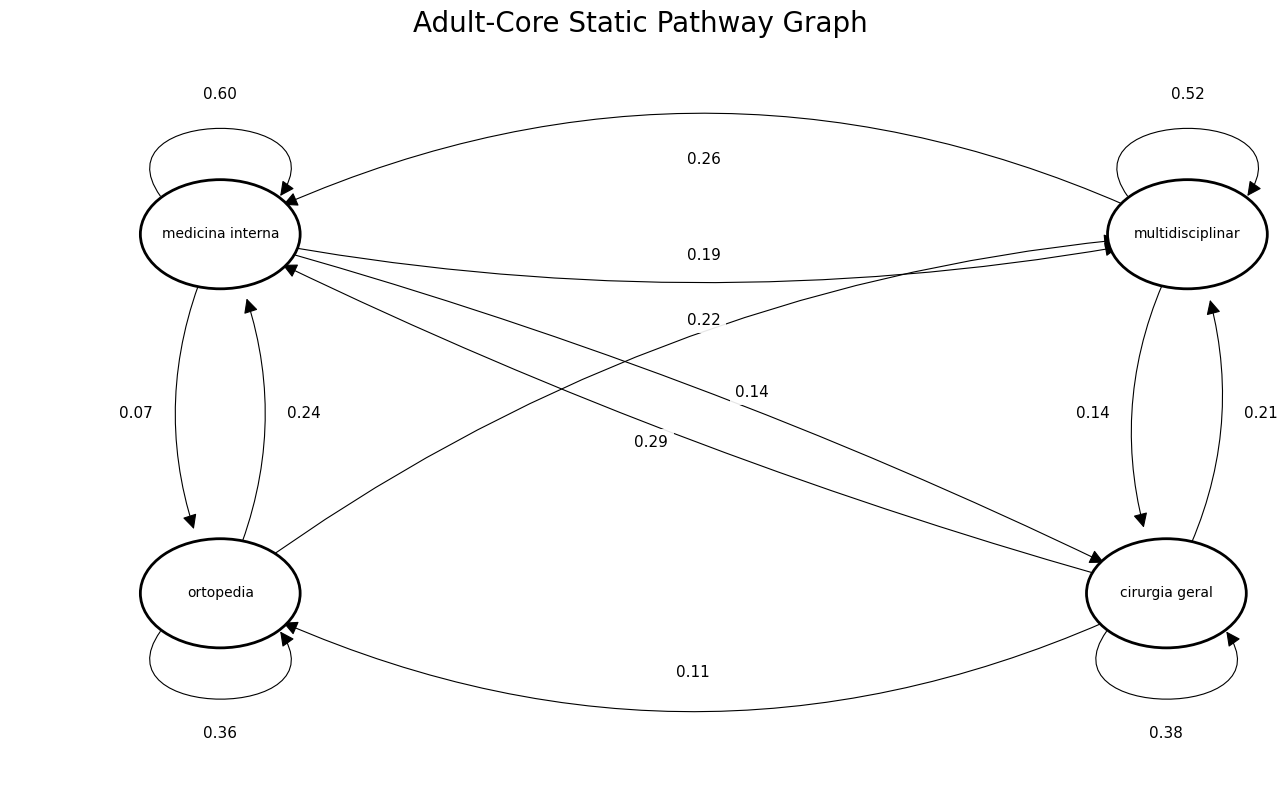

In [ ]:
# ==========================================
# 2. Draw Adult-Core Static Pathway Graph
# ==========================================

# Fixed node positions
pos_adult = {
    "medicina interna": (0, 1),
    "multidisciplinar": (4.6, 1),
    "ortopedia": (0, -1.5),
    "cirurgia geral": (4.5, -1.5)
}

node_radius = 0.38

fig, ax = plt.subplots(figsize=(13, 8))

ax.set_title(
    "Adult-Core Static Pathway Graph",
    fontsize=20
)

# ==========================================
# Draw nodes
# ==========================================

for node, (x, y) in pos_adult.items():
    circle = Circle(
        (x, y),
        radius=node_radius,
        facecolor="white",
        edgecolor="black",
        linewidth=2,
        zorder=3
    )
    ax.add_patch(circle)

    ax.text(
        x,
        y,
        node,
        ha="center",
        va="center",
        fontsize=10,
        color="black",
        zorder=4
    )


# ==========================================
# Helper function to get probability
# ==========================================

def get_adult_prob(from_state, to_state):
    row = adult_core_probs[
        (adult_core_probs["from_state"] == from_state) &
        (adult_core_probs["to_state"] == to_state)
    ]

    if row.empty:
        return None

    return float(row["probability"].iloc[0])


# ==========================================
# Helper function to draw arrows
# ==========================================

def draw_arrow_model(source, target, curve=0.0, label_shift=(0, 0), loop_side="auto"):
    probability = get_adult_prob(source, target)

    if probability is None:
        return

    x1, y1 = pos_adult[source]

    # Self-loop
    if source == target:
        if loop_side == "auto":
            loop_side = "down" if y1 < 0 else "up"

        if loop_side == "up":
            loop_path = Path(
                [
                    (x1 - node_radius * 0.75, y1 + node_radius * 0.70),
                    (x1 - node_radius * 1.55, y1 + node_radius * 2.35),
                    (x1 + node_radius * 1.55, y1 + node_radius * 2.35),
                    (x1 + node_radius * 0.75, y1 + node_radius * 0.70),
                ],
                [
                    Path.MOVETO,
                    Path.CURVE4,
                    Path.CURVE4,
                    Path.CURVE4,
                ]
            )

            label_x = x1 + label_shift[0]
            label_y = y1 + node_radius * 2.25 + label_shift[1]

        else:
            loop_path = Path(
                [
                    (x1 - node_radius * 0.75, y1 - node_radius * 0.70),
                    (x1 - node_radius * 1.55, y1 - node_radius * 2.35),
                    (x1 + node_radius * 1.55, y1 - node_radius * 2.35),
                    (x1 + node_radius * 0.75, y1 - node_radius * 0.70),
                ],
                [
                    Path.MOVETO,
                    Path.CURVE4,
                    Path.CURVE4,
                    Path.CURVE4,
                ]
            )

            label_x = x1 + label_shift[0]
            label_y = y1 - node_radius * 2.25 + label_shift[1]

        arrow = FancyArrowPatch(
            path=loop_path,
            arrowstyle="-|>",
            mutation_scale=22,
            linewidth=0.8,
            color="black",
            zorder=2
        )
        ax.add_patch(arrow)

    # Normal edge
    else:
        x2, y2 = pos_adult[target]

        arrow = FancyArrowPatch(
            (x1, y1),
            (x2, y2),
            arrowstyle="-|>",
            mutation_scale=22,
            linewidth=0.8,
            color="black",
            connectionstyle=f"arc3,rad={curve}",
            shrinkA=28,
            shrinkB=50,
            zorder=2
        )

        ax.add_patch(arrow)

        label_x = (x1 + x2) / 2 + label_shift[0]
        label_y = (y1 + y2) / 2 + label_shift[1]

    # Probability label
    ax.text(
        label_x,
        label_y,
        f"{probability:.2f}",
        fontsize=11,
        color="black",
        ha="center",
        va="center",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.9
        ),
        zorder=5
    )


# ==========================================
# Draw adult-core graph structure
# ==========================================

# Self-loops
draw_arrow_model(
    "medicina interna",
    "medicina interna",
    loop_side="up",
    label_shift=(0, 0.12)
)

draw_arrow_model(
    "multidisciplinar",
    "multidisciplinar",
    loop_side="up",
    label_shift=(0, 0.12)
)

draw_arrow_model(
    "ortopedia",
    "ortopedia",
    loop_side="down",
    label_shift=(0, -0.12)
)

draw_arrow_model(
    "cirurgia geral",
    "cirurgia geral",
    loop_side="down",
    label_shift=(0, -0.12)
)

# Cross-state transitions
draw_arrow_model(
    "medicina interna",
    "multidisciplinar",
    curve=0.10,
    label_shift=(0, -0.15)
)

draw_arrow_model(
    "multidisciplinar",
    "medicina interna",
    curve=0.25,
    label_shift=(0, 0.52)
)

draw_arrow_model(
    "medicina interna",
    "cirurgia geral",
    curve=-0.05,
    label_shift=(0.28, 0.15)
)

draw_arrow_model(
    "cirurgia geral",
    "medicina interna",
    curve=-0.05,
    label_shift=(-0.20, -0.2)
)

draw_arrow_model(
    "cirurgia geral",
    "multidisciplinar",
    curve=0.25,
    label_shift=(0.40, 0)
)

draw_arrow_model(
    "multidisciplinar",
    "cirurgia geral",
    curve=0.25,
    label_shift=(-0.4, 0)
)

draw_arrow_model(
    "medicina interna",
    "ortopedia",
    curve=0.25,
    label_shift=(-0.4, 0)
)

draw_arrow_model(
    "ortopedia",
    "medicina interna",
    curve=0.25,
    label_shift=(0.4, 0)
)

draw_arrow_model(
    "ortopedia",
    "multidisciplinar",
    curve=-0.15,
    label_shift=(0, 0.65)
)

draw_arrow_model(
    "cirurgia geral",
    "ortopedia",
    curve=-0.25,
    label_shift=(0, -0.55)
)

# ==========================================
# Formatting and save
# ==========================================

ax.set_xlim(-1, 5)
ax.set_ylim(-2.8, 2.35)
ax.axis("off")
plt.tight_layout()

plt.savefig(
    "adult_core_static_pathway_graph.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Pediatric static transition table

In [ ]:
# ==========================================
# Pediatric Static Transition Table
# Observed from_state -> to_state counts and probabilities
# ==========================================

pediatric_departments = [
    "pediatria",
    "cirurgia pediátrica"
]

pediatric_transition_df = transition_model_df_filtered[
    transition_model_df_filtered["from_state"].isin(pediatric_departments) &
    transition_model_df_filtered["to_state"].isin(pediatric_departments)
].copy()

pediatric_static_counts = (
    pediatric_transition_df
    .groupby(["from_state", "to_state"])
    .size()
    .reset_index(name="count")
)

pediatric_static_totals = (
    pediatric_transition_df
    .groupby("from_state")
    .size()
    .reset_index(name="total_from_state")
)

pediatric_static_probs = pediatric_static_counts.merge(
    pediatric_static_totals,
    on="from_state",
    how="left"
)

pediatric_static_probs["probability"] = (
    pediatric_static_probs["count"] /
    pediatric_static_probs["total_from_state"]
)

pediatric_static_probs = pediatric_static_probs.sort_values(
    ["from_state", "probability"],
    ascending=[True, False]
).reset_index(drop=True)

pediatric_static_probs

,from_state,to_state,count,total_from_state,probability
0,cirurgia pediátrica,pediatria,4450,5437,0.818466
1,cirurgia pediátrica,cirurgia pediátrica,987,5437,0.181534
2,pediatria,pediatria,111819,116519,0.959663
3,pediatria,cirurgia pediátrica,4700,116519,0.040337


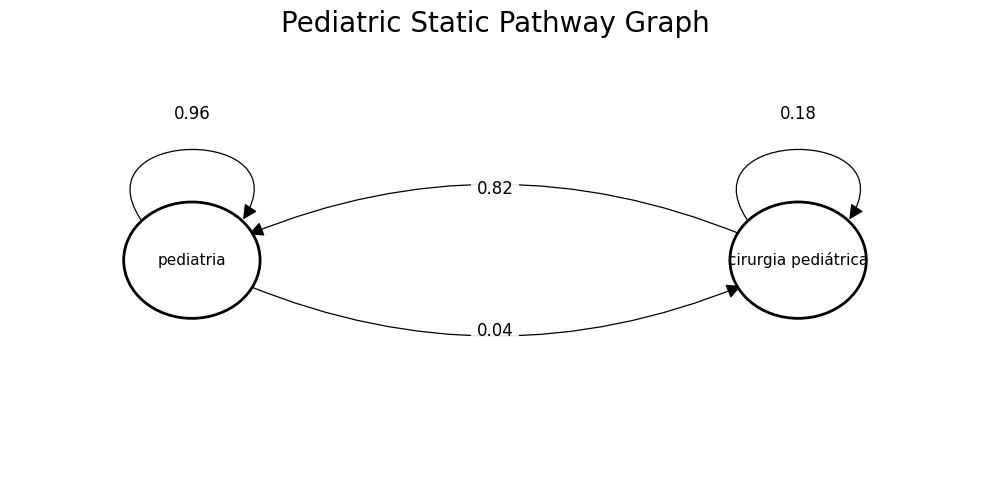

In [ ]:
# ==========================================
# Pediatric Static Pathway Graph - corrected arrow directions
# ==========================================

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Circle
from matplotlib.path import Path

pediatric_probs = pediatric_static_probs[
    ["from_state", "to_state", "probability"]
].copy()

pediatric_probs["probability"] = pediatric_probs["probability"].astype(float)

pos_pediatric = {
    "pediatria": (0, 0),
    "cirurgia pediátrica": (4, 0)
}

node_radius = 0.45

fig, ax = plt.subplots(figsize=(10, 5))

ax.set_title(
    "Pediatric Static Pathway Graph",
    fontsize=20
)

# Draw nodes
for node, (x, y) in pos_pediatric.items():
    circle = Circle(
        (x, y),
        radius=node_radius,
        facecolor="white",
        edgecolor="black",
        linewidth=2,
        zorder=3
    )
    ax.add_patch(circle)

    ax.text(
        x,
        y,
        node,
        ha="center",
        va="center",
        fontsize=11,
        color="black",
        zorder=4
    )


def get_pediatric_prob(from_state, to_state):
    row = pediatric_probs[
        (pediatric_probs["from_state"] == from_state) &
        (pediatric_probs["to_state"] == to_state)
    ]

    if row.empty:
        return None

    return float(row["probability"].iloc[0])


def draw_pediatric_arrow(source, target, curve=0.0, label_shift=(0, 0), loop_side="up"):
    probability = get_pediatric_prob(source, target)

    if probability is None:
        return

    x1, y1 = pos_pediatric[source]

    # Self-loop
    if source == target:
        if loop_side == "up":
            loop_path = Path(
                [
                    (x1 - node_radius * 0.75, y1 + node_radius * 0.70),
                    (x1 - node_radius * 1.65, y1 + node_radius * 2.30),
                    (x1 + node_radius * 1.65, y1 + node_radius * 2.30),
                    (x1 + node_radius * 0.75, y1 + node_radius * 0.70),
                ],
                [
                    Path.MOVETO,
                    Path.CURVE4,
                    Path.CURVE4,
                    Path.CURVE4,
                ]
            )

            label_x = x1 + label_shift[0]
            label_y = y1 + node_radius * 2.25 + label_shift[1]

        else:
            loop_path = Path(
                [
                    (x1 - node_radius * 0.75, y1 - node_radius * 0.70),
                    (x1 - node_radius * 1.65, y1 - node_radius * 2.30),
                    (x1 + node_radius * 1.65, y1 - node_radius * 2.30),
                    (x1 + node_radius * 0.75, y1 - node_radius * 0.70),
                ],
                [
                    Path.MOVETO,
                    Path.CURVE4,
                    Path.CURVE4,
                    Path.CURVE4,
                ]
            )

            label_x = x1 + label_shift[0]
            label_y = y1 - node_radius * 2.25 + label_shift[1]

        arrow = FancyArrowPatch(
            path=loop_path,
            arrowstyle="-|>",
            mutation_scale=22,
            linewidth=0.9,
            color="black",
            zorder=2
        )
        ax.add_patch(arrow)

    # Normal edge
    else:
        x2, y2 = pos_pediatric[target]

        arrow = FancyArrowPatch(
            (x1, y1),
            (x2, y2),
            arrowstyle="-|>",
            mutation_scale=22,
            linewidth=0.9,
            color="black",
            connectionstyle=f"arc3,rad={curve}",
            shrinkA=45,
            shrinkB=45,
            zorder=2
        )
        ax.add_patch(arrow)

        label_x = (x1 + x2) / 2 + label_shift[0]
        label_y = (y1 + y2) / 2 + label_shift[1]

    ax.text(
        label_x,
        label_y,
        f"{probability:.2f}",
        fontsize=12,
        color="black",
        ha="center",
        va="center",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.9
        ),
        zorder=5
    )


# Self-loops
draw_pediatric_arrow(
    "pediatria",
    "pediatria",
    loop_side="up",
    label_shift=(0, 0.12)
)

draw_pediatric_arrow(
    "cirurgia pediátrica",
    "cirurgia pediátrica",
    loop_side="up",
    label_shift=(0, 0.12)
)

# Cross transitions
# cirurgia pediátrica -> pediatria = 0.82
# This is the upper arrow pointing left
draw_pediatric_arrow(
    "cirurgia pediátrica",
    "pediatria",
    curve=0.25,
    label_shift=(0, 0.55)
)

# pediatria -> cirurgia pediátrica = 0.04
# This is the lower arrow pointing right
draw_pediatric_arrow(
    "pediatria",
    "cirurgia pediátrica",
    curve=0.25,
    label_shift=(0, -0.55)
)

ax.set_xlim(-1.2, 5.2)
ax.set_ylim(-1.7, 1.7)
ax.axis("off")
plt.tight_layout()

plt.savefig(
    "pediatric_static_pathway_graph.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ==========================================
# Gynecology/Obstetrics Two-Node Static Transition Table
# Observed from_state -> to_state counts and probabilities
# ==========================================

gyn_obs_departments = [
    "obstetrícia",
    "ginecologia"
]

gyn_obs_transition_df = transition_model_df_filtered[
    transition_model_df_filtered["from_state"].isin(gyn_obs_departments) &
    transition_model_df_filtered["to_state"].isin(gyn_obs_departments)
].copy()

gyn_obs_static_counts = (
    gyn_obs_transition_df
    .groupby(["from_state", "to_state"])
    .size()
    .reset_index(name="count")
)

gyn_obs_static_totals = (
    gyn_obs_transition_df
    .groupby("from_state")
    .size()
    .reset_index(name="total_from_state")
)

gyn_obs_static_probs = gyn_obs_static_counts.merge(
    gyn_obs_static_totals,
    on="from_state",
    how="left"
)

gyn_obs_static_probs["probability"] = (
    gyn_obs_static_probs["count"] /
    gyn_obs_static_probs["total_from_state"]
)

gyn_obs_static_probs = gyn_obs_static_probs.sort_values(
    ["from_state", "probability"],
    ascending=[True, False]
).reset_index(drop=True)

gyn_obs_static_probs

,from_state,to_state,count,total_from_state,probability
0,ginecologia,ginecologia,2461,3116,0.789795
1,ginecologia,obstetrícia,655,3116,0.210205
2,obstetrícia,obstetrícia,48151,48776,0.987186
3,obstetrícia,ginecologia,625,48776,0.012814


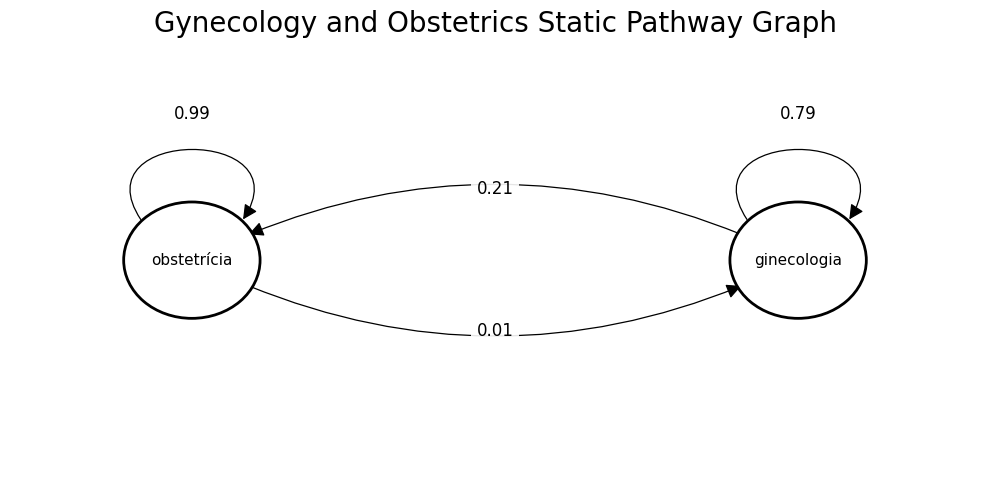

In [ ]:
# ==========================================
# Gynecology/Obstetrics Two-Node Static Pathway Graph
# Probabilities written directly in arrow calls
# ==========================================

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Circle
from matplotlib.path import Path

# Fixed node positions
pos_gyn_obs = {
    "obstetrícia": (0, 0),
    "ginecologia": (4, 0)
}

node_radius = 0.45

fig, ax = plt.subplots(figsize=(10, 5))

ax.set_title(
    "Gynecology and Obstetrics Static Pathway Graph",
    fontsize=20
)

# Draw nodes
for node, (x, y) in pos_gyn_obs.items():
    circle = Circle(
        (x, y),
        radius=node_radius,
        facecolor="white",
        edgecolor="black",
        linewidth=2,
        zorder=3
    )
    ax.add_patch(circle)

    ax.text(
        x,
        y,
        node,
        ha="center",
        va="center",
        fontsize=11,
        color="black",
        zorder=4
    )


def draw_gyn_obs_arrow(
    source,
    target,
    probability,
    curve=0.0,
    label_shift=(0, 0),
    loop_side="up"
):
    x1, y1 = pos_gyn_obs[source]

    # Self-loop
    if source == target:
        if loop_side == "up":
            loop_path = Path(
                [
                    (x1 - node_radius * 0.75, y1 + node_radius * 0.70),
                    (x1 - node_radius * 1.65, y1 + node_radius * 2.30),
                    (x1 + node_radius * 1.65, y1 + node_radius * 2.30),
                    (x1 + node_radius * 0.75, y1 + node_radius * 0.70),
                ],
                [
                    Path.MOVETO,
                    Path.CURVE4,
                    Path.CURVE4,
                    Path.CURVE4,
                ]
            )

            label_x = x1 + label_shift[0]
            label_y = y1 + node_radius * 2.25 + label_shift[1]

        else:
            loop_path = Path(
                [
                    (x1 - node_radius * 0.75, y1 - node_radius * 0.70),
                    (x1 - node_radius * 1.65, y1 - node_radius * 2.30),
                    (x1 + node_radius * 1.65, y1 - node_radius * 2.30),
                    (x1 + node_radius * 0.75, y1 - node_radius * 0.70),
                ],
                [
                    Path.MOVETO,
                    Path.CURVE4,
                    Path.CURVE4,
                    Path.CURVE4,
                ]
            )

            label_x = x1 + label_shift[0]
            label_y = y1 - node_radius * 2.25 + label_shift[1]

        arrow = FancyArrowPatch(
            path=loop_path,
            arrowstyle="-|>",
            mutation_scale=22,
            linewidth=0.9,
            color="black",
            zorder=2
        )
        ax.add_patch(arrow)

    # Normal edge
    else:
        x2, y2 = pos_gyn_obs[target]

        arrow = FancyArrowPatch(
            (x1, y1),
            (x2, y2),
            arrowstyle="-|>",
            mutation_scale=22,
            linewidth=0.9,
            color="black",
            connectionstyle=f"arc3,rad={curve}",
            shrinkA=45,
            shrinkB=45,
            zorder=2
        )

        ax.add_patch(arrow)

        label_x = (x1 + x2) / 2 + label_shift[0]
        label_y = (y1 + y2) / 2 + label_shift[1]

    ax.text(
        label_x,
        label_y,
        f"{probability:.2f}",
        fontsize=12,
        color="black",
        ha="center",
        va="center",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.9
        ),
        zorder=5
    )


# ==========================================
# Draw graph edges
# Replace these probabilities if table gives different rounded values
# ==========================================

# obstetrícia -> obstetrícia
draw_gyn_obs_arrow(
    "obstetrícia",
    "obstetrícia",
    probability=0.99,
    loop_side="up",
    label_shift=(0, 0.12)
)

# ginecologia -> ginecologia
draw_gyn_obs_arrow(
    "ginecologia",
    "ginecologia",
    probability=0.79,
    loop_side="up",
    label_shift=(0, 0.12)
)

# obstetrícia -> ginecologia
draw_gyn_obs_arrow(
    "obstetrícia",
    "ginecologia",
    probability=0.01,
    curve=0.25,
    label_shift=(0, -0.55)
)

# ginecologia -> obstetrícia
draw_gyn_obs_arrow(
    "ginecologia",
    "obstetrícia",
    probability=0.21,
    curve=0.25,
    label_shift=(0, 0.55)
)

# Formatting
ax.set_xlim(-1.2, 5.2)
ax.set_ylim(-1.7, 1.7)
ax.axis("off")
plt.tight_layout()

plt.savefig(
    "gynecology_obstetrics_static_pathway_graph.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ==========================================
# Cardio-vascular + Intensive Care Static Transition Table
# Low-count node removed: cirurgia cardio-torácica
# ==========================================

cardio_departments = [
    "medicina interna",
    "cardiologia",
    "angiologia e cirurgia vascular",
    "medicina intensiva"
]

cardio_transition_df = transition_model_df_filtered[
    transition_model_df_filtered["from_state"].isin(cardio_departments) &
    transition_model_df_filtered["to_state"].isin(cardio_departments)
].copy()

cardio_static_counts = (
    cardio_transition_df
    .groupby(["from_state", "to_state"])
    .size()
    .reset_index(name="count")
)

cardio_static_totals = (
    cardio_transition_df
    .groupby("from_state")
    .size()
    .reset_index(name="total_from_state")
)

cardio_static_probs = cardio_static_counts.merge(
    cardio_static_totals,
    on="from_state",
    how="left"
)

cardio_static_probs["probability"] = (
    cardio_static_probs["count"] /
    cardio_static_probs["total_from_state"]
)

cardio_static_probs = cardio_static_probs.sort_values(
    ["from_state", "probability"],
    ascending=[True, False]
).reset_index(drop=True)

cardio_static_probs

,from_state,to_state,count,total_from_state,probability
0,angiologia e cirurgia vascular,medicina interna,151,302,0.500000
1,angiologia e cirurgia vascular,angiologia e cirurgia vascular,139,302,0.460265
2,angiologia e cirurgia vascular,cardiologia,6,302,0.019868
3,angiologia e cirurgia vascular,medicina intensiva,6,302,0.019868
4,cardiologia,medicina interna,577,800,0.721250
5,cardiologia,cardiologia,202,800,0.252500
6,cardiologia,medicina intensiva,12,800,0.015000
7,cardiologia,angiologia e cirurgia vascular,9,800,0.011250
8,medicina intensiva,medicina interna,102,115,0.886957
9,medicina intensiva,medicina intensiva,9,115,0.078261


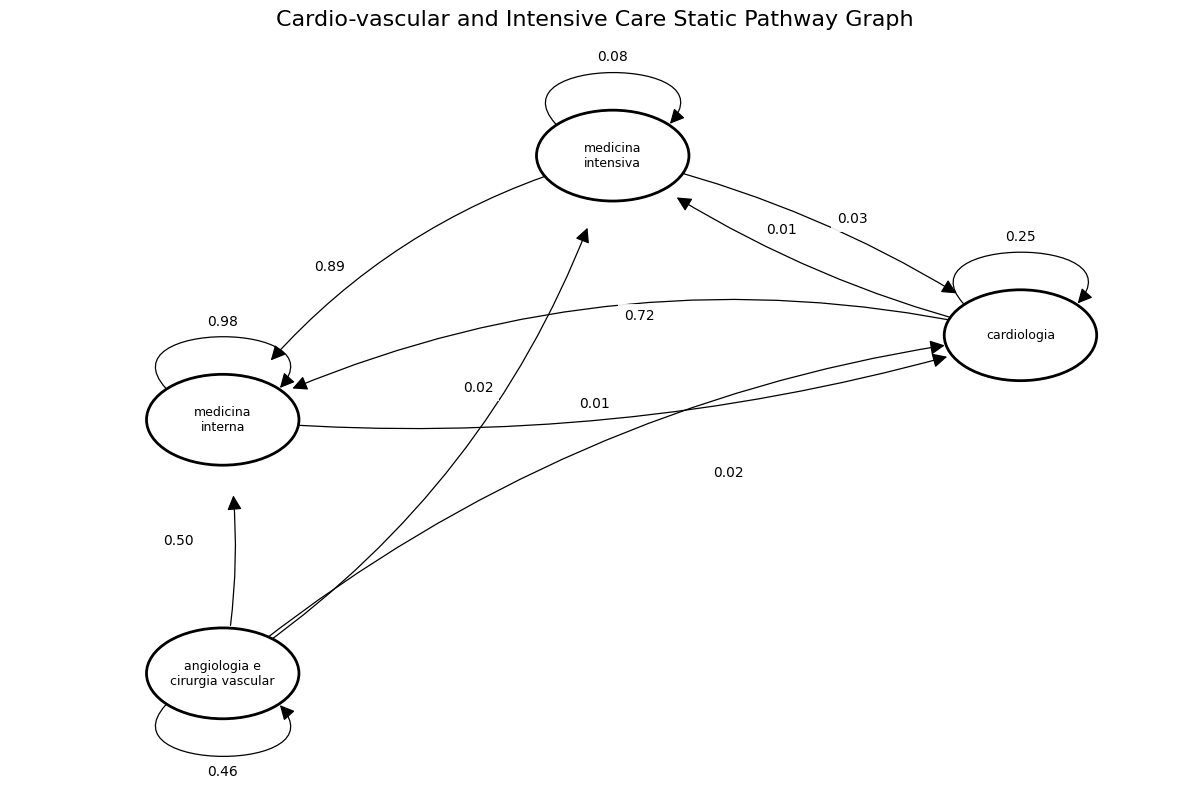

In [ ]:
# ==========================================
# Cardio-vascular + Intensive Care Static Pathway Graph
# Same style as old notebook, but low-count node removed
# ==========================================

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Circle
from matplotlib.path import Path

# ==========================================
# Helper: get updated probability from table
# ==========================================

def get_static_prob(prob_df, source, target):
    row = prob_df[
        (prob_df["from_state"] == source) &
        (prob_df["to_state"] == target)
    ]

    if row.empty:
        print(f"Missing edge: {source} -> {target}")
        return None

    return float(row["probability"].iloc[0])


# ==========================================
# Fixed node positions
# ==========================================

pos_cardio = {
    "medicina interna": (0, 0),
    "cardiologia": (4.5, 0.8),
    "angiologia e cirurgia vascular": (0, -2.4),
    "medicina intensiva": (2.2, 2.5)
}

node_labels = {
    "medicina interna": "medicina\ninterna",
    "cardiologia": "cardiologia",
    "angiologia e cirurgia vascular": "angiologia e\ncirurgia vascular",
    "medicina intensiva": "medicina\nintensiva"
}

fig, ax = plt.subplots(figsize=(12, 8))

ax.set_title(
    "Cardio-vascular and Intensive Care Static Pathway Graph",
    fontsize=16,
    pad=25
)

node_radius = 0.43

# ==========================================
# Draw nodes
# ==========================================

for node, (x, y) in pos_cardio.items():
    circle = Circle(
        (x, y),
        radius=node_radius,
        facecolor="white",
        edgecolor="black",
        linewidth=2,
        zorder=3
    )

    ax.add_patch(circle)

    ax.text(
        x,
        y,
        node_labels[node],
        ha="center",
        va="center",
        fontsize=9,
        color="black",
        zorder=4
    )


# ==========================================
# Helper function for arrows
# ==========================================

def draw_cardio_arrow(
    source,
    target,
    probability,
    curve=0.0,
    label_shift=(0, 0),
    loop_side="up"
):
    if probability is None:
        return

    x1, y1 = pos_cardio[source]

    # Self-loop
    if source == target:

        if loop_side == "up":
            loop_path = Path(
                [
                    (x1 - node_radius * 0.75, y1 + node_radius * 0.70),
                    (x1 - node_radius * 1.55, y1 + node_radius * 2.20),
                    (x1 + node_radius * 1.55, y1 + node_radius * 2.20),
                    (x1 + node_radius * 0.75, y1 + node_radius * 0.70),
                ],
                [
                    Path.MOVETO,
                    Path.CURVE4,
                    Path.CURVE4,
                    Path.CURVE4,
                ]
            )

            label_x = x1 + label_shift[0]
            label_y = y1 + node_radius * 2.05 + label_shift[1]

        else:
            loop_path = Path(
                [
                    (x1 - node_radius * 0.75, y1 - node_radius * 0.70),
                    (x1 - node_radius * 1.55, y1 - node_radius * 2.20),
                    (x1 + node_radius * 1.55, y1 - node_radius * 2.20),
                    (x1 + node_radius * 0.75, y1 - node_radius * 0.70),
                ],
                [
                    Path.MOVETO,
                    Path.CURVE4,
                    Path.CURVE4,
                    Path.CURVE4,
                ]
            )

            label_x = x1 + label_shift[0]
            label_y = y1 - node_radius * 2.05 + label_shift[1]

        arrow = FancyArrowPatch(
            path=loop_path,
            arrowstyle="-|>",
            mutation_scale=22,
            linewidth=0.9,
            color="black",
            zorder=2
        )

        ax.add_patch(arrow)

    # Normal arrow
    else:
        x2, y2 = pos_cardio[target]

        arrow = FancyArrowPatch(
            (x1, y1),
            (x2, y2),
            arrowstyle="-|>",
            mutation_scale=22,
            linewidth=0.9,
            color="black",
            connectionstyle=f"arc3,rad={curve}",
            shrinkA=35,
            shrinkB=55,
            zorder=2
        )

        ax.add_patch(arrow)

        label_x = (x1 + x2) / 2 + label_shift[0]
        label_y = (y1 + y2) / 2 + label_shift[1]

    ax.text(
        label_x,
        label_y,
        f"{probability:.2f}",
        fontsize=10,
        color="black",
        ha="center",
        va="center",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.9
        ),
        zorder=5
    )


# ==========================================
# Self-loops
# ==========================================

draw_cardio_arrow(
    "medicina interna",
    "medicina interna",
    get_static_prob(cardio_static_probs, "medicina interna", "medicina interna"),
    loop_side="up",
    label_shift=(0, 0.05)
)

draw_cardio_arrow(
    "cardiologia",
    "cardiologia",
    get_static_prob(cardio_static_probs, "cardiologia", "cardiologia"),
    loop_side="up",
    label_shift=(0, 0.05)
)

draw_cardio_arrow(
    "angiologia e cirurgia vascular",
    "angiologia e cirurgia vascular",
    get_static_prob(cardio_static_probs, "angiologia e cirurgia vascular", "angiologia e cirurgia vascular"),
    loop_side="down",
    label_shift=(0, -0.05)
)

draw_cardio_arrow(
    "medicina intensiva",
    "medicina intensiva",
    get_static_prob(cardio_static_probs, "medicina intensiva", "medicina intensiva"),
    loop_side="up",
    label_shift=(0, 0.05)
)


# ==========================================
# Main transitions toward medicina interna
# ==========================================

draw_cardio_arrow(
    "cardiologia",
    "medicina interna",
    get_static_prob(cardio_static_probs, "cardiologia", "medicina interna"),
    curve=0.18,
    label_shift=(0.10, 0.58)
)

draw_cardio_arrow(
    "medicina intensiva",
    "medicina interna",
    get_static_prob(cardio_static_probs, "medicina intensiva", "medicina interna"),
    curve=0.18,
    label_shift=(-0.50, 0.20)
)

draw_cardio_arrow(
    "angiologia e cirurgia vascular",
    "medicina interna",
    get_static_prob(cardio_static_probs, "angiologia e cirurgia vascular", "medicina interna"),
    curve=0.10,
    label_shift=(-0.25, 0.05)
)


# ==========================================
# Smaller relevant transitions
# ==========================================

draw_cardio_arrow(
    "medicina interna",
    "cardiologia",
    get_static_prob(cardio_static_probs, "medicina interna", "cardiologia"),
    curve=0.10,
    label_shift=(-0.15, -0.25)
)

draw_cardio_arrow(
    "medicina intensiva",
    "cardiologia",
    get_static_prob(cardio_static_probs, "medicina intensiva", "cardiologia"),
    curve=-0.10,
    label_shift=(0.2, 0.25)
)

draw_cardio_arrow(
    "cardiologia",
    "medicina intensiva",
    get_static_prob(cardio_static_probs, "cardiologia", "medicina intensiva"),
    curve=-0.10,
    label_shift=(-0.20, 0.15)
)

draw_cardio_arrow(
    "angiologia e cirurgia vascular",
    "cardiologia",
    get_static_prob(cardio_static_probs, "angiologia e cirurgia vascular", "cardiologia"),
    curve=-0.15,
    label_shift=(0.6, 0.30)
)

draw_cardio_arrow(
    "angiologia e cirurgia vascular",
    "medicina intensiva",
    get_static_prob(cardio_static_probs, "angiologia e cirurgia vascular", "medicina intensiva"),
    curve=0.18,
    label_shift=(0.34, 0.25)
)


# ==========================================
# Final formatting
# ==========================================

ax.set_xlim(-1.2, 5.4)
ax.set_ylim(-3.4, 3.4)

ax.axis("off")
plt.tight_layout()

plt.savefig(
    "cardio_intensive_care_static_pathway_graph.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ==========================================
# Respiratory / Pneumology Static Transition Table
# Observed from_state -> to_state counts and probabilities
# ==========================================

resp_departments = [
    "medicina interna",
    "multidisciplinar",
    "cirurgia geral",
    "ortopedia",
    "pneumologia"
]

resp_transition_df = transition_model_df_filtered[
    transition_model_df_filtered["from_state"].isin(resp_departments) &
    transition_model_df_filtered["to_state"].isin(resp_departments)
].copy()

resp_static_counts = (
    resp_transition_df
    .groupby(["from_state", "to_state"])
    .size()
    .reset_index(name="count")
)

resp_static_totals = (
    resp_transition_df
    .groupby("from_state")
    .size()
    .reset_index(name="total_from_state")
)

resp_static_probs = resp_static_counts.merge(
    resp_static_totals,
    on="from_state",
    how="left"
)

resp_static_probs["probability"] = (
    resp_static_probs["count"] /
    resp_static_probs["total_from_state"]
)

resp_static_probs = resp_static_probs.sort_values(
    ["from_state", "probability"],
    ascending=[True, False]
).reset_index(drop=True)

resp_static_probs

,from_state,to_state,count,total_from_state,probability
0,cirurgia geral,cirurgia geral,14953,39357,0.379932
1,cirurgia geral,medicina interna,11480,39357,0.291689
2,cirurgia geral,multidisciplinar,8400,39357,0.213431
3,cirurgia geral,ortopedia,4364,39357,0.110882
4,cirurgia geral,pneumologia,160,39357,0.004065
5,medicina interna,medicina interna,50558,85303,0.592687
6,medicina interna,multidisciplinar,15944,85303,0.186910
7,medicina interna,cirurgia geral,12063,85303,0.141414
8,medicina interna,ortopedia,6022,85303,0.070595
9,medicina interna,pneumologia,716,85303,0.008394


In [ ]:
# ==========================================
# Select authentic graph edges from new results
# Rule: show transitions with probability >= 0.05
# ==========================================

edge_threshold = 0.05

resp_graph_edges = resp_static_probs[
    resp_static_probs["probability"] >= edge_threshold
].copy()

resp_graph_edges = resp_graph_edges.sort_values(
    ["from_state", "probability"],
    ascending=[True, False]
).reset_index(drop=True)

print("Number of displayed edges:", resp_graph_edges.shape[0])
resp_graph_edges

Number of displayed edges: 21


,from_state,to_state,count,total_from_state,probability
0,cirurgia geral,cirurgia geral,14953,39357,0.379932
1,cirurgia geral,medicina interna,11480,39357,0.291689
2,cirurgia geral,multidisciplinar,8400,39357,0.213431
3,cirurgia geral,ortopedia,4364,39357,0.110882
4,medicina interna,medicina interna,50558,85303,0.592687
5,medicina interna,multidisciplinar,15944,85303,0.186910
6,medicina interna,cirurgia geral,12063,85303,0.141414
7,medicina interna,ortopedia,6022,85303,0.070595
8,multidisciplinar,multidisciplinar,24327,46601,0.522027
9,multidisciplinar,medicina interna,12062,46601,0.258836


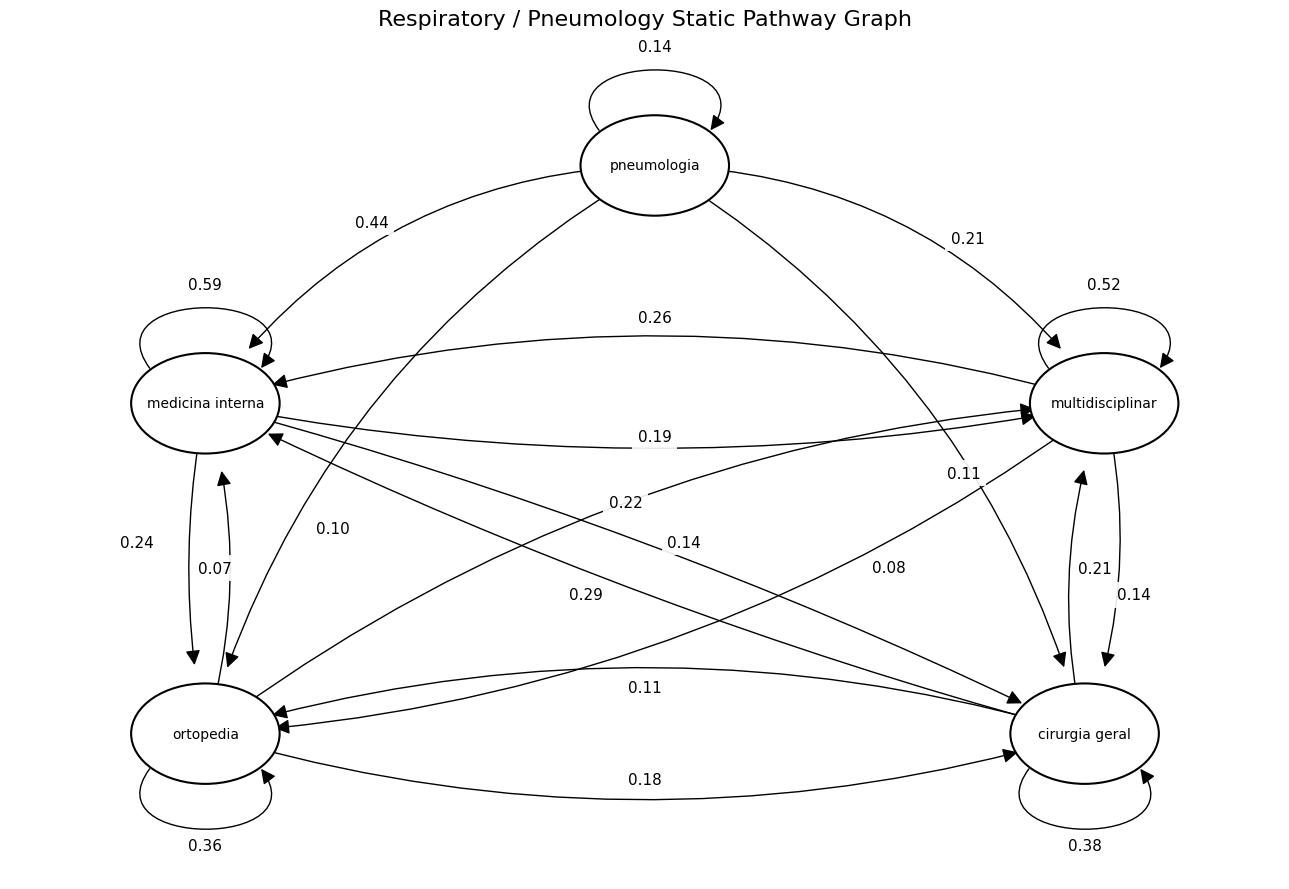

In [ ]:
# ==========================================
# Respiratory / Pneumology Static Pathway Graph
# Authentic data-based edges
# Probabilities written directly in arrow calls for easy editing
# ==========================================

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Circle
from matplotlib.path import Path

# ==========================================
# Node positions from old graph, used only for layout
# ==========================================

pos_respiratory = {
    "medicina interna": (0, 1),
    "multidisciplinar": (4.6, 1),
    "ortopedia": (0, -1.5),
    "cirurgia geral": (4.5, -1.5),
    "pneumologia": (2.3, 2.8)
}

fig, ax = plt.subplots(figsize=(13, 9))

ax.set_title(
    "Respiratory / Pneumology Static Pathway Graph",
    fontsize=16
)

node_radius = 0.38

# ==========================================
# Draw nodes
# ==========================================

for node, (x, y) in pos_respiratory.items():
    circle = Circle(
        (x, y),
        radius=node_radius,
        facecolor="white",
        edgecolor="black",
        linewidth=1.5,
        zorder=3
    )
    ax.add_patch(circle)

    ax.text(
        x,
        y,
        node,
        ha="center",
        va="center",
        fontsize=10,
        color="black",
        zorder=4
    )


# ==========================================
# Helper function for arrows
# ==========================================

def draw_respiratory_arrow(
    source,
    target,
    probability,
    curve=0.0,
    label_shift=(0, 0),
    loop_side="auto"
):
    x1, y1 = pos_respiratory[source]

    # Self-loop
    if source == target:
        if loop_side == "auto":
            loop_side = "up" if y1 >= 0 else "down"

        if loop_side == "up":
            loop_path = Path(
                [
                    (x1 - node_radius * 0.75, y1 + node_radius * 0.70),
                    (x1 - node_radius * 1.55, y1 + node_radius * 2.30),
                    (x1 + node_radius * 1.55, y1 + node_radius * 2.30),
                    (x1 + node_radius * 0.75, y1 + node_radius * 0.70),
                ],
                [
                    Path.MOVETO,
                    Path.CURVE4,
                    Path.CURVE4,
                    Path.CURVE4,
                ]
            )

            label_x = x1 + label_shift[0]
            label_y = y1 + node_radius * 2.10 + label_shift[1]

        else:
            loop_path = Path(
                [
                    (x1 - node_radius * 0.75, y1 - node_radius * 0.70),
                    (x1 - node_radius * 1.55, y1 - node_radius * 2.30),
                    (x1 + node_radius * 1.55, y1 - node_radius * 2.30),
                    (x1 + node_radius * 0.75, y1 - node_radius * 0.70),
                ],
                [
                    Path.MOVETO,
                    Path.CURVE4,
                    Path.CURVE4,
                    Path.CURVE4,
                ]
            )

            label_x = x1 + label_shift[0]
            label_y = y1 - node_radius * 2.10 + label_shift[1]

        arrow = FancyArrowPatch(
            path=loop_path,
            arrowstyle="-|>",
            mutation_scale=22,
            linewidth=1,
            color="black",
            zorder=2
        )
        ax.add_patch(arrow)

    # Normal arrow
    else:
        x2, y2 = pos_respiratory[target]

        arrow = FancyArrowPatch(
            (x1, y1),
            (x2, y2),
            arrowstyle="-|>",
            mutation_scale=22,
            linewidth=1,
            color="black",
            connectionstyle=f"arc3,rad={curve}",
            shrinkA=28,
            shrinkB=50,
            zorder=2
        )
        ax.add_patch(arrow)

        label_x = (x1 + x2) / 2 + label_shift[0]
        label_y = (y1 + y2) / 2 + label_shift[1]

    ax.text(
        label_x,
        label_y,
        f"{probability:.2f}",
        fontsize=11,
        color="black",
        ha="center",
        va="center",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.9
        ),
        zorder=5
    )


# ==========================================
# Authentic edges from new respiratory table
# Rule used earlier: probability >= 0.05
# Edit label_shift=(x, y) to move labels
# ==========================================

# --------------------------
# cirurgia geral outgoing edges
# --------------------------

draw_respiratory_arrow(
    "cirurgia geral",
    "cirurgia geral",
    0.379932,
    loop_side="down",
    label_shift=(0, -0.05)
)

draw_respiratory_arrow(
    "cirurgia geral",
    "medicina interna",
    0.291689,
    curve=-0.05,
    label_shift=(-0.30, -0.20)
)

draw_respiratory_arrow(
    "cirurgia geral",
    "multidisciplinar",
    0.213431,
    curve=-0.15,
    label_shift=(0,0)
)

draw_respiratory_arrow(
    "cirurgia geral",
    "ortopedia",
    0.110882,
    curve=0.15,
    label_shift=(0, 0.35)
)


# --------------------------
# medicina interna outgoing edges
# --------------------------

draw_respiratory_arrow(
    "medicina interna",
    "medicina interna",
    0.592687,
    loop_side="up",
    label_shift=(0, 0.10)
)

draw_respiratory_arrow(
    "medicina interna",
    "multidisciplinar",
    0.186910,
    curve=0.10,
    label_shift=(0, -0.25)
)

draw_respiratory_arrow(
    "medicina interna",
    "cirurgia geral",
    0.141414,
    curve=-0.05,
    label_shift=(0.20, 0.20)
)

draw_respiratory_arrow(
    "medicina interna",
    "ortopedia",
    0.070595,
    curve=0.10,
    label_shift=(0.05, 0)
)


# --------------------------
# multidisciplinar outgoing edges
# --------------------------

draw_respiratory_arrow(
    "multidisciplinar",
    "multidisciplinar",
    0.522027,
    loop_side="up",
    label_shift=(0, 0.10)
)

draw_respiratory_arrow(
    "multidisciplinar",
    "medicina interna",
    0.258836,
    curve=0.15,
    label_shift=(0, 0.65)
)

draw_respiratory_arrow(
    "multidisciplinar",
    "cirurgia geral",
    0.136885,
    curve=-0.15,
    label_shift=(0.20, -0.20)
)

draw_respiratory_arrow(
    "multidisciplinar",
    "ortopedia",
    0.077144,
    curve=-0.15,
    label_shift=(1.2, 0.01)
)


# --------------------------
# ortopedia outgoing edges
# --------------------------

draw_respiratory_arrow(
    "ortopedia",
    "ortopedia",
    0.356428,
    loop_side="down",
    label_shift=(0, -0.05)
)

draw_respiratory_arrow(
    "ortopedia",
    "medicina interna",
    0.235268,
    curve=0.15,
    label_shift=(-0.35, 0.20)
)

draw_respiratory_arrow(
    "ortopedia",
    "multidisciplinar",
    0.223633,
    curve=-0.15,
    label_shift=(-0.15, 0.50)
)

draw_respiratory_arrow(
    "ortopedia",
    "cirurgia geral",
    0.179735,
    curve=0.15,
    label_shift=(0, -0.35)
)


# --------------------------
# pneumologia outgoing edges
# --------------------------

draw_respiratory_arrow(
    "pneumologia",
    "medicina interna",
    0.435881,
    curve=0.25,
    label_shift=(-0.30, 0.47)
)

draw_respiratory_arrow(
    "pneumologia",
    "multidisciplinar",
    0.214378,
    curve=-0.25,
    label_shift=(0.45, 0.35)
)

draw_respiratory_arrow(
    "pneumologia",
    "pneumologia",
    0.141839,
    loop_side="up",
    label_shift=(0, 0.10)
)

draw_respiratory_arrow(
    "pneumologia",
    "cirurgia geral",
    0.112694,
    curve=-0.20,
    label_shift=(0.48, -0.18)
)

draw_respiratory_arrow(
    "pneumologia",
    "ortopedia",
    0.095207,
    curve=0.20,
    label_shift=(-0.5, -0.60)
)


# ==========================================
# Final formatting
# ==========================================

ax.set_xlim(-1, 5.5)
ax.set_ylim(-2.6, 3.8)

ax.axis("off")
plt.tight_layout()

plt.savefig(
    "respiratory_pneumology_static_pathway_graph.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ==========================================
# Neurology Static Transition Table
# Authentic data-based transitions
# ==========================================

neuro_departments = [
    "medicina interna",
    "multidisciplinar",
    "neurologia",
    "neurocirurgia",
    "medicina intensiva"
]

neuro_transition_df = transition_model_df_filtered[
    transition_model_df_filtered["from_state"].isin(neuro_departments) &
    transition_model_df_filtered["to_state"].isin(neuro_departments)
].copy()

neuro_static_counts = (
    neuro_transition_df
    .groupby(["from_state", "to_state"])
    .size()
    .reset_index(name="count")
)

neuro_static_totals = (
    neuro_transition_df
    .groupby("from_state")
    .size()
    .reset_index(name="total_from_state")
)

neuro_static_probs = neuro_static_counts.merge(
    neuro_static_totals,
    on="from_state",
    how="left"
)

neuro_static_probs["probability"] = (
    neuro_static_probs["count"] /
    neuro_static_probs["total_from_state"]
)

neuro_static_probs = neuro_static_probs.sort_values(
    ["from_state", "probability"],
    ascending=[True, False]
).reset_index(drop=True)

neuro_static_probs

,from_state,to_state,count,total_from_state,probability
0,medicina intensiva,medicina interna,102,182,0.560440
1,medicina intensiva,multidisciplinar,41,182,0.225275
2,medicina intensiva,neurologia,26,182,0.142857
3,medicina intensiva,medicina intensiva,9,182,0.049451
4,medicina intensiva,neurocirurgia,4,182,0.021978
5,medicina interna,medicina interna,50558,69441,0.728071
6,medicina interna,multidisciplinar,15944,69441,0.229605
7,medicina interna,neurologia,2603,69441,0.037485
8,medicina interna,medicina intensiva,227,69441,0.003269
9,medicina interna,neurocirurgia,109,69441,0.001570


In [ ]:
# ==========================================
# Select authentic graph edges
# Rule: show transitions with probability >= 0.10
# ==========================================

edge_threshold = 0.10

neuro_graph_edges = neuro_static_probs[
    neuro_static_probs["probability"] >= edge_threshold
].copy()

neuro_graph_edges = neuro_graph_edges.sort_values(
    ["from_state", "probability"],
    ascending=[True, False]
).reset_index(drop=True)

print("Number of displayed edges:", neuro_graph_edges.shape[0])
neuro_graph_edges

Number of displayed edges: 14


,from_state,to_state,count,total_from_state,probability
0,medicina intensiva,medicina interna,102,182,0.560440
1,medicina intensiva,multidisciplinar,41,182,0.225275
2,medicina intensiva,neurologia,26,182,0.142857
3,medicina interna,medicina interna,50558,69441,0.728071
4,medicina interna,multidisciplinar,15944,69441,0.229605
5,multidisciplinar,multidisciplinar,24327,38038,0.639545
6,multidisciplinar,medicina interna,12062,38038,0.317104
7,neurocirurgia,neurocirurgia,236,571,0.413310
8,neurocirurgia,medicina interna,140,571,0.245184
9,neurocirurgia,multidisciplinar,109,571,0.190893


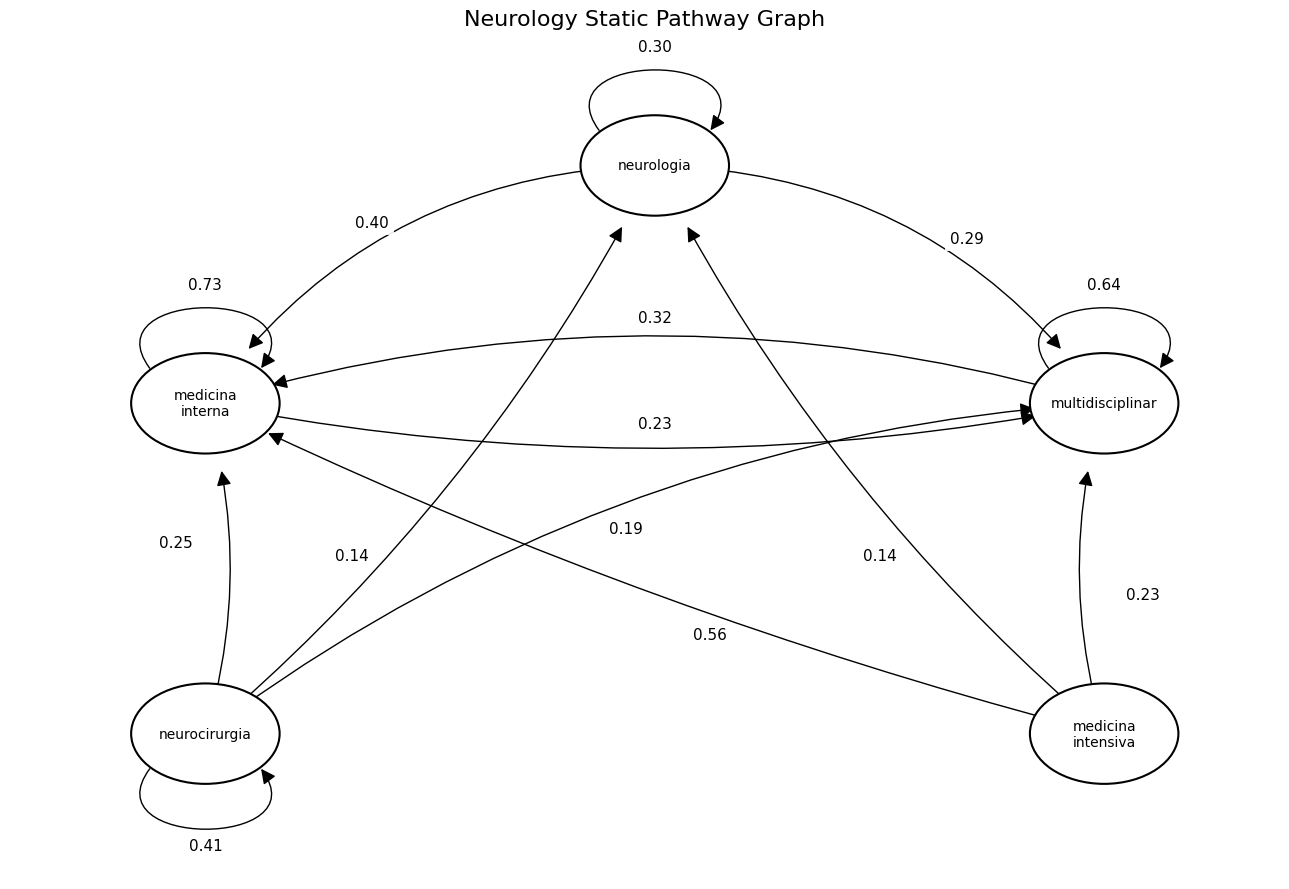

In [ ]:
# ==========================================
# Neurology Static Pathway Graph
# Authentic data-based edges
# Probabilities written directly in arrow calls
# ==========================================

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Circle
from matplotlib.path import Path

# ==========================================
# Node positions
# ==========================================

pos_neuro = {
    "medicina interna": (0, 1),
    "multidisciplinar": (4.6, 1),
    "neurologia": (2.3, 2.8),
    "neurocirurgia": (0, -1.5),
    "medicina intensiva": (4.6, -1.5)
}

node_labels = {
    "medicina interna": "medicina\ninterna",
    "multidisciplinar": "multidisciplinar",
    "neurologia": "neurologia",
    "neurocirurgia": "neurocirurgia",
    "medicina intensiva": "medicina\nintensiva"
}

fig, ax = plt.subplots(figsize=(13, 9))

ax.set_title(
    "Neurology Static Pathway Graph",
    fontsize=16
)

node_radius = 0.38

# ==========================================
# Draw nodes
# ==========================================

for node, (x, y) in pos_neuro.items():
    circle = Circle(
        (x, y),
        radius=node_radius,
        facecolor="white",
        edgecolor="black",
        linewidth=1.5,
        zorder=3
    )
    ax.add_patch(circle)

    ax.text(
        x,
        y,
        node_labels[node],
        ha="center",
        va="center",
        fontsize=10,
        color="black",
        zorder=4
    )


# ==========================================
# Helper function for arrows
# ==========================================

def draw_neuro_arrow(
    source,
    target,
    probability,
    curve=0.0,
    label_shift=(0, 0),
    loop_side="auto"
):
    x1, y1 = pos_neuro[source]

    # Self-loop
    if source == target:
        if loop_side == "auto":
            loop_side = "up" if y1 >= 0 else "down"

        if loop_side == "up":
            loop_path = Path(
                [
                    (x1 - node_radius * 0.75, y1 + node_radius * 0.70),
                    (x1 - node_radius * 1.55, y1 + node_radius * 2.30),
                    (x1 + node_radius * 1.55, y1 + node_radius * 2.30),
                    (x1 + node_radius * 0.75, y1 + node_radius * 0.70),
                ],
                [
                    Path.MOVETO,
                    Path.CURVE4,
                    Path.CURVE4,
                    Path.CURVE4,
                ]
            )

            label_x = x1 + label_shift[0]
            label_y = y1 + node_radius * 2.10 + label_shift[1]

        else:
            loop_path = Path(
                [
                    (x1 - node_radius * 0.75, y1 - node_radius * 0.70),
                    (x1 - node_radius * 1.55, y1 - node_radius * 2.30),
                    (x1 + node_radius * 1.55, y1 - node_radius * 2.30),
                    (x1 + node_radius * 0.75, y1 - node_radius * 0.70),
                ],
                [
                    Path.MOVETO,
                    Path.CURVE4,
                    Path.CURVE4,
                    Path.CURVE4,
                ]
            )

            label_x = x1 + label_shift[0]
            label_y = y1 - node_radius * 2.10 + label_shift[1]

        arrow = FancyArrowPatch(
            path=loop_path,
            arrowstyle="-|>",
            mutation_scale=22,
            linewidth=1,
            color="black",
            zorder=2
        )
        ax.add_patch(arrow)

    # Normal arrow
    else:
        x2, y2 = pos_neuro[target]

        arrow = FancyArrowPatch(
            (x1, y1),
            (x2, y2),
            arrowstyle="-|>",
            mutation_scale=22,
            linewidth=1,
            color="black",
            connectionstyle=f"arc3,rad={curve}",
            shrinkA=28,
            shrinkB=50,
            zorder=2
        )
        ax.add_patch(arrow)

        label_x = (x1 + x2) / 2 + label_shift[0]
        label_y = (y1 + y2) / 2 + label_shift[1]

    ax.text(
        label_x,
        label_y,
        f"{probability:.2f}",
        fontsize=11,
        color="black",
        ha="center",
        va="center",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.9
        ),
        zorder=5
    )


# ==========================================
# Authentic edges from neuro_graph_edges
# Rule: probability >= 0.10
# Edit label_shift=(x, y) if labels overlap
# ==========================================

# --------------------------
# medicina intensiva outgoing edges
# --------------------------

draw_neuro_arrow(
    "medicina intensiva",
    "medicina interna",
    0.560440,
    curve=-0.05,
    label_shift=(0.28, -0.5)
)

draw_neuro_arrow(
    "medicina intensiva",
    "multidisciplinar",
    0.225275,
    curve=-0.15,
    label_shift=(0.20, -0.20)
)

draw_neuro_arrow(
    "medicina intensiva",
    "neurologia",
    0.142857,
    curve=-0.10,
    label_shift=(0, -0.8)
)


# --------------------------
# medicina interna outgoing edges
# --------------------------

draw_neuro_arrow(
    "medicina interna",
    "medicina interna",
    0.728071,
    loop_side="up",
    label_shift=(0, 0.10)
)

draw_neuro_arrow(
    "medicina interna",
    "multidisciplinar",
    0.229605,
    curve=0.10,
    label_shift=(0, -0.15)
)


# --------------------------
# multidisciplinar outgoing edges
# --------------------------

draw_neuro_arrow(
    "multidisciplinar",
    "multidisciplinar",
    0.639545,
    loop_side="up",
    label_shift=(0, 0.10)
)

draw_neuro_arrow(
    "multidisciplinar",
    "medicina interna",
    0.317104,
    curve=0.15,
    label_shift=(0, 0.65)
)


# --------------------------
# neurocirurgia outgoing edges
# --------------------------

draw_neuro_arrow(
    "neurocirurgia",
    "neurocirurgia",
    0.413310,
    loop_side="down",
    label_shift=(0, -0.05)
)

draw_neuro_arrow(
    "neurocirurgia",
    "medicina interna",
    0.245184,
    curve=0.15,
    label_shift=(-0.15, 0.2)
)

draw_neuro_arrow(
    "neurocirurgia",
    "multidisciplinar",
    0.190893,
    curve=-0.15,
    label_shift=(-0.15, 0.30)
)

draw_neuro_arrow(
    "neurocirurgia",
    "neurologia",
    0.140105,
    curve=0.10,
    label_shift=(-0.4, -0.8)
)


# --------------------------
# neurologia outgoing edges
# --------------------------

draw_neuro_arrow(
    "neurologia",
    "medicina interna",
    0.397566,
    curve=0.25,
    label_shift=(-0.30, 0.47)
)

draw_neuro_arrow(
    "neurologia",
    "neurologia",
    0.298431,
    loop_side="up",
    label_shift=(0, 0.10)
)

draw_neuro_arrow(
    "neurologia",
    "multidisciplinar",
    0.285526,
    curve=-0.25,
    label_shift=(0.45, 0.35)
)


# ==========================================
# Final formatting
# ==========================================

ax.set_xlim(-1, 5.5)
ax.set_ylim(-2.6, 3.8)

ax.axis("off")
plt.tight_layout()

plt.savefig(
    "neurology_static_pathway_graph.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Gastroenterology / Digestive Static Pathway Graph.

In [ ]:
# ==========================================
# Gastroenterology / Digestive Static Transition Table
# Authentic data-based transitions
# ==========================================

# Detect whether the dataset uses "gastroenterologia" or "gastrenterologia"
all_states = set(transition_model_df_filtered["from_state"].unique()).union(
    set(transition_model_df_filtered["to_state"].unique())
)

if "gastroenterologia" in all_states:
    gastro_node = "gastroenterologia"
elif "gastrenterologia" in all_states:
    gastro_node = "gastrenterologia"
else:
    gastro_node = None
    print("Could not find gastroenterology department name in the data.")

gastro_departments = [
    "medicina interna",
    "multidisciplinar",
    "cirurgia geral",
    gastro_node
]

gastro_departments = [x for x in gastro_departments if x is not None]

gastro_transition_df = transition_model_df_filtered[
    transition_model_df_filtered["from_state"].isin(gastro_departments) &
    transition_model_df_filtered["to_state"].isin(gastro_departments)
].copy()

gastro_static_counts = (
    gastro_transition_df
    .groupby(["from_state", "to_state"])
    .size()
    .reset_index(name="count")
)

gastro_static_totals = (
    gastro_transition_df
    .groupby("from_state")
    .size()
    .reset_index(name="total_from_state")
)

gastro_static_probs = gastro_static_counts.merge(
    gastro_static_totals,
    on="from_state",
    how="left"
)

gastro_static_probs["probability"] = (
    gastro_static_probs["count"] /
    gastro_static_probs["total_from_state"]
)

gastro_static_probs = gastro_static_probs.sort_values(
    ["from_state", "probability"],
    ascending=[True, False]
).reset_index(drop=True)

print("Departments used:", gastro_departments)
gastro_static_probs

Departments used: ['medicina interna', 'multidisciplinar', 'cirurgia geral', 'gastroenterologia']


,from_state,to_state,count,total_from_state,probability
0,cirurgia geral,cirurgia geral,14953,34970,0.427595
1,cirurgia geral,medicina interna,11480,34970,0.328281
2,cirurgia geral,multidisciplinar,8400,34970,0.240206
3,cirurgia geral,gastroenterologia,137,34970,0.003918
4,gastroenterologia,medicina interna,218,616,0.353896
5,gastroenterologia,gastroenterologia,171,616,0.277597
6,gastroenterologia,cirurgia geral,128,616,0.207792
7,gastroenterologia,multidisciplinar,99,616,0.160714
8,medicina interna,medicina interna,50558,78794,0.641648
9,medicina interna,multidisciplinar,15944,78794,0.202350


In [ ]:
# ==========================================
# Select authentic graph edges
# Rule: show transitions with probability >= 0.10
# ==========================================

edge_threshold = 0.10

gastro_graph_edges = gastro_static_probs[
    gastro_static_probs["probability"] >= edge_threshold
].copy()

gastro_graph_edges = gastro_graph_edges.sort_values(
    ["from_state", "probability"],
    ascending=[True, False]
).reset_index(drop=True)

print("Number of displayed edges:", gastro_graph_edges.shape[0])
gastro_graph_edges

Number of displayed edges: 13


,from_state,to_state,count,total_from_state,probability
0,cirurgia geral,cirurgia geral,14953,34970,0.427595
1,cirurgia geral,medicina interna,11480,34970,0.328281
2,cirurgia geral,multidisciplinar,8400,34970,0.240206
3,gastroenterologia,medicina interna,218,616,0.353896
4,gastroenterologia,gastroenterologia,171,616,0.277597
5,gastroenterologia,cirurgia geral,128,616,0.207792
6,gastroenterologia,multidisciplinar,99,616,0.160714
7,medicina interna,medicina interna,50558,78794,0.641648
8,medicina interna,multidisciplinar,15944,78794,0.202350
9,medicina interna,cirurgia geral,12063,78794,0.153095


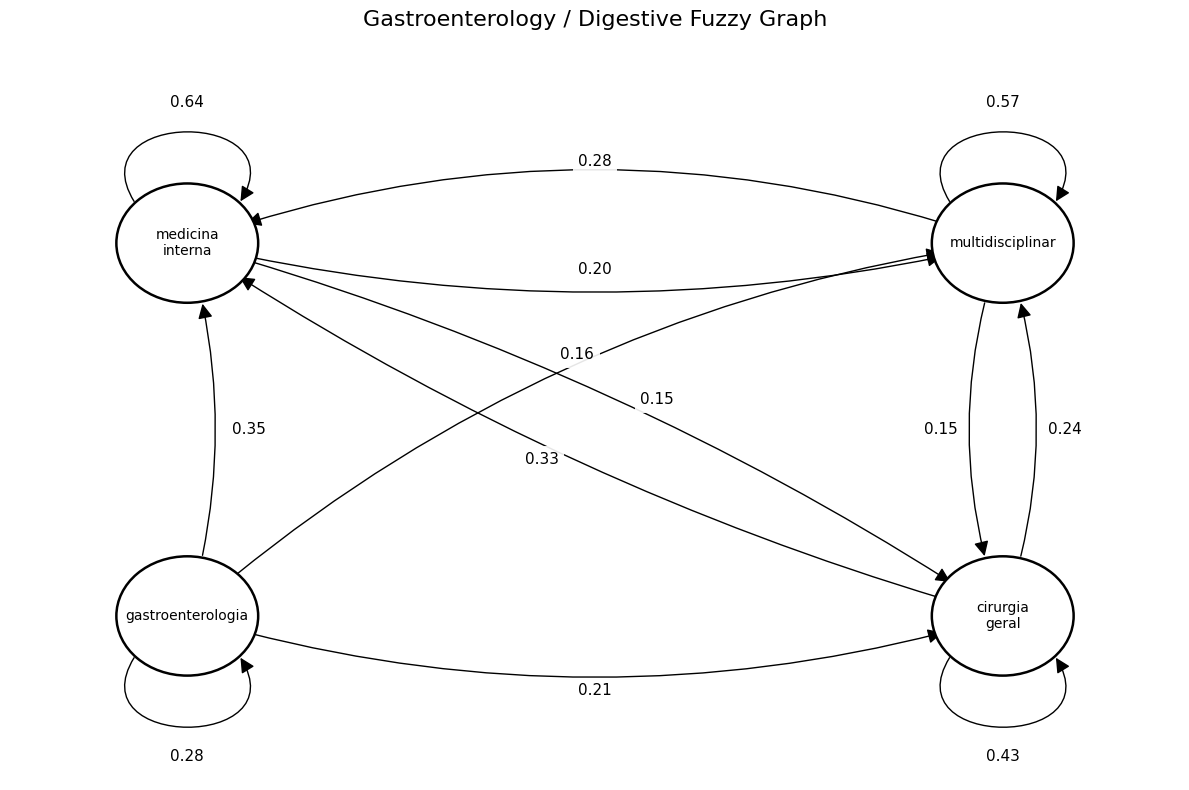

In [ ]:
# ==========================================
# Gastroenterology / Digestive Fuzzy Graph
# Authentic data-based edges from gastro_graph_edges
# ==========================================

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Circle
from matplotlib.path import Path

# Make sure gastro_node exists
gastro_node = "gastroenterologia"

# ==========================================
# Node positions
# ==========================================

pos_gastro = {
    "medicina interna": (0, 1),
    "multidisciplinar": (4.6, 1),
    "cirurgia geral": (4.6, -1.5),
    "gastroenterologia": (0, -1.5)
}

node_labels = {
    "medicina interna": "medicina\ninterna",
    "multidisciplinar": "multidisciplinar",
    "cirurgia geral": "cirurgia\ngeral",
    "gastroenterologia": "gastroenterologia"
}

fig, ax = plt.subplots(figsize=(12, 8))

ax.set_title(
    "Gastroenterology / Digestive Fuzzy Graph",
    fontsize=16
)

node_radius = 0.40

# ==========================================
# Draw nodes
# ==========================================

for node, (x, y) in pos_gastro.items():
    circle = Circle(
        (x, y),
        radius=node_radius,
        facecolor="white",
        edgecolor="black",
        linewidth=1.8,
        zorder=3
    )
    ax.add_patch(circle)

    ax.text(
        x,
        y,
        node_labels[node],
        ha="center",
        va="center",
        fontsize=10,
        color="black",
        zorder=4
    )

# ==========================================
# Curve and label placement maps
# These are only for layout, not for changing probabilities
# ==========================================

curve_map = {
    ("medicina interna", "multidisciplinar"): 0.12,
    ("multidisciplinar", "medicina interna"): 0.18,

    ("medicina interna", "cirurgia geral"): -0.08,
    ("cirurgia geral", "medicina interna"): -0.08,

    ("gastroenterologia", "medicina interna"): 0.15,

    ("multidisciplinar", "cirurgia geral"): 0.18,
    ("cirurgia geral", "multidisciplinar"): 0.18,

    ("gastroenterologia", "multidisciplinar"): -0.15,

    ("gastroenterologia", "cirurgia geral"): 0.15,
}

label_shift_map = {
    ("medicina interna", "medicina interna"): (0, 0.10),
    ("multidisciplinar", "multidisciplinar"): (0, 0.10),
    ("cirurgia geral", "cirurgia geral"): (0, -0.10),
    ("gastroenterologia", "gastroenterologia"): (0, -0.10),

    ("medicina interna", "multidisciplinar"): (0, -0.18),
    ("multidisciplinar", "medicina interna"): (0, 0.55),

    ("medicina interna", "cirurgia geral"): (0.35, 0.20),
    ("cirurgia geral", "medicina interna"): (-0.30, -0.20),

    ("gastroenterologia", "medicina interna"): (0.35, 0.00),

    ("multidisciplinar", "cirurgia geral"): (-0.35, 0.00),
    ("cirurgia geral", "multidisciplinar"): (0.35, 0.00),

    ("gastroenterologia", "multidisciplinar"): (-0.10, 0.50),

    ("gastroenterologia", "cirurgia geral"): (0, -0.50),
}

# ==========================================
# Helper function
# ==========================================

def draw_gastro_arrow(
    source,
    target,
    probability,
    curve=0.0,
    label_shift=(0, 0),
    loop_side="auto"
):
    x1, y1 = pos_gastro[source]

    # Self-loop
    if source == target:
        if loop_side == "auto":
            loop_side = "up" if y1 >= 0 else "down"

        if loop_side == "up":
            loop_path = Path(
                [
                    (x1 - node_radius * 0.75, y1 + node_radius * 0.70),
                    (x1 - node_radius * 1.55, y1 + node_radius * 2.25),
                    (x1 + node_radius * 1.55, y1 + node_radius * 2.25),
                    (x1 + node_radius * 0.75, y1 + node_radius * 0.70),
                ],
                [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4]
            )

            label_x = x1 + label_shift[0]
            label_y = y1 + node_radius * 2.10 + label_shift[1]

        else:
            loop_path = Path(
                [
                    (x1 - node_radius * 0.75, y1 - node_radius * 0.70),
                    (x1 - node_radius * 1.55, y1 - node_radius * 2.25),
                    (x1 + node_radius * 1.55, y1 - node_radius * 2.25),
                    (x1 + node_radius * 0.75, y1 - node_radius * 0.70),
                ],
                [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4]
            )

            label_x = x1 + label_shift[0]
            label_y = y1 - node_radius * 2.10 + label_shift[1]

        arrow = FancyArrowPatch(
            path=loop_path,
            arrowstyle="-|>",
            mutation_scale=22,
            linewidth=1,
            color="black",
            zorder=2
        )
        ax.add_patch(arrow)

    # Normal edge
    else:
        x2, y2 = pos_gastro[target]

        arrow = FancyArrowPatch(
            (x1, y1),
            (x2, y2),
            arrowstyle="-|>",
            mutation_scale=22,
            linewidth=1,
            color="black",
            connectionstyle=f"arc3,rad={curve}",
            shrinkA=45,
            shrinkB=45,
            zorder=2
        )
        ax.add_patch(arrow)

        label_x = (x1 + x2) / 2 + label_shift[0]
        label_y = (y1 + y2) / 2 + label_shift[1]

    ax.text(
        label_x,
        label_y,
        f"{probability:.2f}",
        fontsize=11,
        color="black",
        ha="center",
        va="center",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.9
        ),
        zorder=5
    )

# ==========================================
# Draw only edges that actually exist in gastro_graph_edges
# This guarantees graph probabilities match the table
# ==========================================

for _, row in gastro_graph_edges.iterrows():
    source = row["from_state"]
    target = row["to_state"]
    probability = row["probability"]

    # Skip anything outside selected nodes, just in case
    if source not in pos_gastro or target not in pos_gastro:
        continue

    curve = curve_map.get((source, target), 0.0)
    label_shift = label_shift_map.get((source, target), (0, 0))

    draw_gastro_arrow(
        source=source,
        target=target,
        probability=probability,
        curve=curve,
        label_shift=label_shift
    )

# ==========================================
# Final formatting
# ==========================================

ax.set_xlim(-1, 5.6)
ax.set_ylim(-2.6, 2.4)
ax.axis("off")
plt.tight_layout()

plt.savefig(
    "gastroenterology.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ==========================================
# Urology Static Transition Table
# Authentic data-based transitions
# ==========================================

uro_departments = [
    "medicina interna",
    "multidisciplinar",
    "cirurgia geral",
    "urologia"
]

uro_transition_df = transition_model_df_filtered[
    transition_model_df_filtered["from_state"].isin(uro_departments) &
    transition_model_df_filtered["to_state"].isin(uro_departments)
].copy()

uro_static_counts = (
    uro_transition_df
    .groupby(["from_state", "to_state"])
    .size()
    .reset_index(name="count")
)

uro_static_totals = (
    uro_transition_df
    .groupby("from_state")
    .size()
    .reset_index(name="total_from_state")
)

uro_static_probs = uro_static_counts.merge(
    uro_static_totals,
    on="from_state",
    how="left"
)

uro_static_probs["probability"] = (
    uro_static_probs["count"] /
    uro_static_probs["total_from_state"]
)

uro_static_probs = uro_static_probs.sort_values(
    ["from_state", "probability"],
    ascending=[True, False]
).reset_index(drop=True)

uro_static_probs

,from_state,to_state,count,total_from_state,probability
0,cirurgia geral,cirurgia geral,14953,35478,0.421472
1,cirurgia geral,medicina interna,11480,35478,0.323581
2,cirurgia geral,multidisciplinar,8400,35478,0.236766
3,cirurgia geral,urologia,645,35478,0.018180
4,medicina interna,medicina interna,50558,79755,0.633916
5,medicina interna,multidisciplinar,15944,79755,0.199912
6,medicina interna,cirurgia geral,12063,79755,0.151251
7,medicina interna,urologia,1190,79755,0.014921
8,multidisciplinar,multidisciplinar,24327,43616,0.557754
9,multidisciplinar,medicina interna,12062,43616,0.276550


In [ ]:
# ==========================================
# Select authentic graph edges
# Rule: show transitions with probability >= 0.10
# ==========================================

edge_threshold = 0.10

uro_graph_edges = uro_static_probs[
    uro_static_probs["probability"] >= edge_threshold
].copy()

uro_graph_edges = uro_graph_edges.sort_values(
    ["from_state", "probability"],
    ascending=[True, False]
).reset_index(drop=True)

print("Number of displayed edges:", uro_graph_edges.shape[0])
uro_graph_edges

Number of displayed edges: 13


,from_state,to_state,count,total_from_state,probability
0,cirurgia geral,cirurgia geral,14953,35478,0.421472
1,cirurgia geral,medicina interna,11480,35478,0.323581
2,cirurgia geral,multidisciplinar,8400,35478,0.236766
3,medicina interna,medicina interna,50558,79755,0.633916
4,medicina interna,multidisciplinar,15944,79755,0.199912
5,medicina interna,cirurgia geral,12063,79755,0.151251
6,multidisciplinar,multidisciplinar,24327,43616,0.557754
7,multidisciplinar,medicina interna,12062,43616,0.276550
8,multidisciplinar,cirurgia geral,6379,43616,0.146254
9,urologia,urologia,2108,4665,0.451876


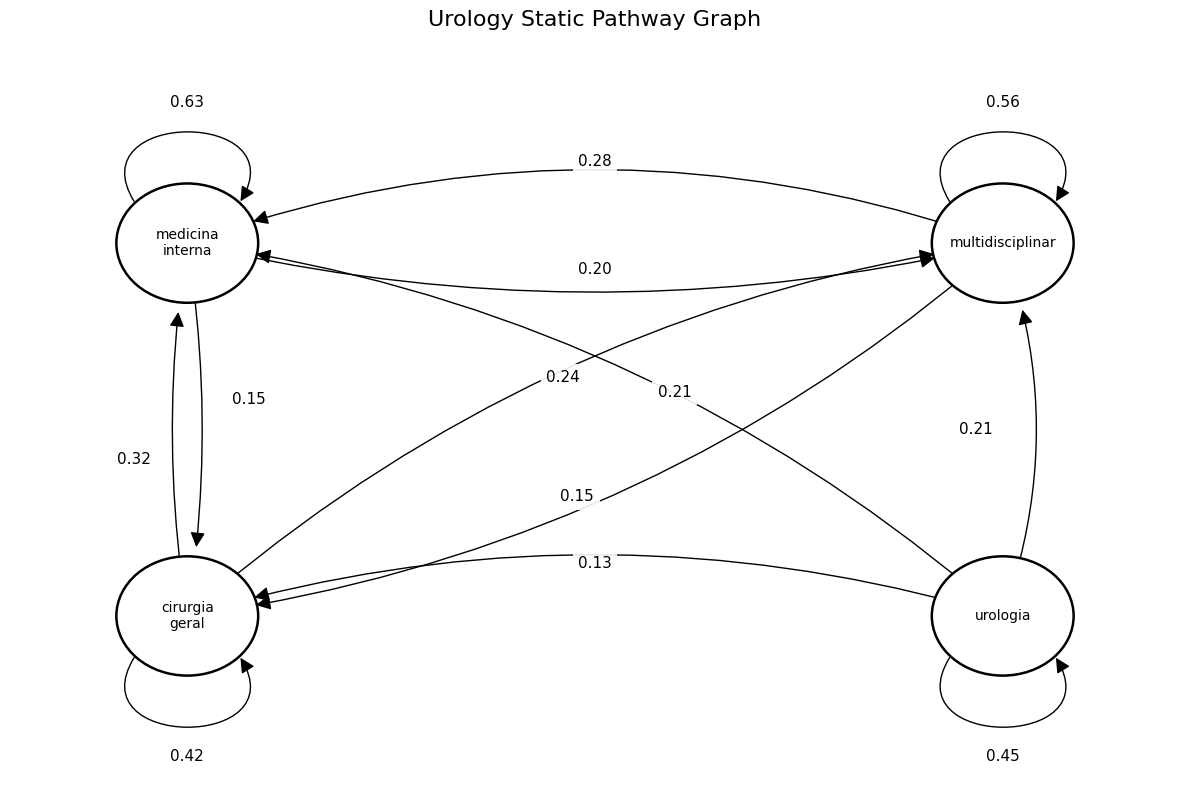

In [ ]:
# ==========================================
# Urology Static Pathway Graph
# Authentic data-based edges
# ==========================================

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Circle
from matplotlib.path import Path

# ==========================================
# Node positions
# ==========================================

pos_uro = {
    "medicina interna": (0, 1),
    "multidisciplinar": (4.6, 1),
    "cirurgia geral": (0, -1.5),
    "urologia": (4.6, -1.5)
}

node_labels = {
    "medicina interna": "medicina\ninterna",
    "multidisciplinar": "multidisciplinar",
    "cirurgia geral": "cirurgia\ngeral",
    "urologia": "urologia"
}

fig, ax = plt.subplots(figsize=(12, 8))

ax.set_title(
    "Urology Static Pathway Graph",
    fontsize=16
)

node_radius = 0.40

# ==========================================
# Draw nodes
# ==========================================

for node, (x, y) in pos_uro.items():
    circle = Circle(
        (x, y),
        radius=node_radius,
        facecolor="white",
        edgecolor="black",
        linewidth=1.8,
        zorder=3
    )
    ax.add_patch(circle)

    ax.text(
        x,
        y,
        node_labels[node],
        ha="center",
        va="center",
        fontsize=10,
        color="black",
        zorder=4
    )


# ==========================================
# Curve and label placement maps
# Edit label_shift_map if labels overlap
# ==========================================

curve_map = {
    ("medicina interna", "multidisciplinar"): 0.12,
    ("multidisciplinar", "medicina interna"): 0.18,

    ("medicina interna", "cirurgia geral"): -0.08,
    ("cirurgia geral", "medicina interna"): -0.08,

    ("medicina interna", "urologia"): 0.15,
    ("urologia", "medicina interna"): 0.15,

    ("multidisciplinar", "cirurgia geral"): -0.15,
    ("cirurgia geral", "multidisciplinar"): -0.15,

    ("multidisciplinar", "urologia"): 0.18,
    ("urologia", "multidisciplinar"): 0.18,

    ("cirurgia geral", "urologia"): 0.15,
    ("urologia", "cirurgia geral"): 0.15,
}

label_shift_map = {
    ("medicina interna", "medicina interna"): (0, 0.10),
    ("multidisciplinar", "multidisciplinar"): (0, 0.10),
    ("cirurgia geral", "cirurgia geral"): (0, -0.10),
    ("urologia", "urologia"): (0, -0.10),

    ("medicina interna", "multidisciplinar"): (0, -0.18),
    ("multidisciplinar", "medicina interna"): (0, 0.55),

    ("medicina interna", "cirurgia geral"): (0.35, 0.20),
    ("cirurgia geral", "medicina interna"): (-0.30, -0.20),

    ("medicina interna", "urologia"): (-0.20, -0.20),
    ("urologia", "medicina interna"): (0.45, 0.25),

    ("multidisciplinar", "cirurgia geral"): (-0.10, -0.45),
    ("cirurgia geral", "multidisciplinar"): (-0.18, 0.35),

    ("multidisciplinar", "urologia"): (0.35, 0.00),
    ("urologia", "multidisciplinar"): (-0.15, 0.00),

    ("cirurgia geral", "urologia"): (0, -0.35),
    ("urologia", "cirurgia geral"): (0, 0.35),
}


# ==========================================
# Helper function
# ==========================================

def draw_uro_arrow(
    source,
    target,
    probability,
    curve=0.0,
    label_shift=(0, 0),
    loop_side="auto"
):
    x1, y1 = pos_uro[source]

    # Self-loop
    if source == target:
        if loop_side == "auto":
            loop_side = "up" if y1 >= 0 else "down"

        if loop_side == "up":
            loop_path = Path(
                [
                    (x1 - node_radius * 0.75, y1 + node_radius * 0.70),
                    (x1 - node_radius * 1.55, y1 + node_radius * 2.25),
                    (x1 + node_radius * 1.55, y1 + node_radius * 2.25),
                    (x1 + node_radius * 0.75, y1 + node_radius * 0.70),
                ],
                [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4]
            )

            label_x = x1 + label_shift[0]
            label_y = y1 + node_radius * 2.10 + label_shift[1]

        else:
            loop_path = Path(
                [
                    (x1 - node_radius * 0.75, y1 - node_radius * 0.70),
                    (x1 - node_radius * 1.55, y1 - node_radius * 2.25),
                    (x1 + node_radius * 1.55, y1 - node_radius * 2.25),
                    (x1 + node_radius * 0.75, y1 - node_radius * 0.70),
                ],
                [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4]
            )

            label_x = x1 + label_shift[0]
            label_y = y1 - node_radius * 2.10 + label_shift[1]

        arrow = FancyArrowPatch(
            path=loop_path,
            arrowstyle="-|>",
            mutation_scale=22,
            linewidth=1,
            color="black",
            zorder=2
        )
        ax.add_patch(arrow)

    # Normal edge
    else:
        x2, y2 = pos_uro[target]

        arrow = FancyArrowPatch(
            (x1, y1),
            (x2, y2),
            arrowstyle="-|>",
            mutation_scale=22,
            linewidth=1,
            color="black",
            connectionstyle=f"arc3,rad={curve}",
            shrinkA=30,
            shrinkB=50,
            zorder=2
        )
        ax.add_patch(arrow)

        label_x = (x1 + x2) / 2 + label_shift[0]
        label_y = (y1 + y2) / 2 + label_shift[1]

    ax.text(
        label_x,
        label_y,
        f"{probability:.2f}",
        fontsize=11,
        color="black",
        ha="center",
        va="center",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.9
        ),
        zorder=5
    )


# ==========================================
# Draw only real edges from uro_graph_edges
# ==========================================

for _, row in uro_graph_edges.iterrows():
    source = row["from_state"]
    target = row["to_state"]
    probability = row["probability"]

    curve = curve_map.get((source, target), 0.0)
    label_shift = label_shift_map.get((source, target), (0, 0))

    draw_uro_arrow(
        source,
        target,
        probability,
        curve=curve,
        label_shift=label_shift
    )


# ==========================================
# Final formatting
# ==========================================

ax.set_xlim(-1, 5.6)
ax.set_ylim(-2.6, 2.4)

ax.axis("off")
plt.tight_layout()

plt.savefig(
    "urology_static_pathway_graph.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ==========================================
# Top incoming departments by transition count
# ==========================================

top_incoming_departments = (
    transition_model_df_filtered
    .groupby("to_state")
    .size()
    .reset_index(name="incoming_transition_count")
    .sort_values("incoming_transition_count", ascending=False)
    .head(11)
    .reset_index(drop=True)
)

top_incoming_departments

,to_state,incoming_transition_count
0,pediatria,117769
1,medicina interna,93269
2,multidisciplinar,67644
3,obstetrícia,52801
4,cirurgia geral,45723
5,ortopedia,26675
6,oftalmologia,17493
7,psiquiatria,9639
8,neurologia,9617
9,otorrinolaringologia,7625


In [ ]:
# ==========================================
# Top outgoing departments by transition count
# ==========================================

top_outgoing_departments = (
    transition_model_df_filtered
    .groupby("from_state")
    .size()
    .reset_index(name="outgoing_transition_count")
    .sort_values("outgoing_transition_count", ascending=False)
    .head(11)
    .reset_index(drop=True)
)

top_outgoing_departments

,from_state,outgoing_transition_count
0,pediatria,120096
1,medicina interna,99823
2,multidisciplinar,56759
3,obstetrícia,52560
4,cirurgia geral,47406
5,ortopedia,26792
6,oftalmologia,18128
7,neurologia,10160
8,psiquiatria,9530
9,otorrinolaringologia,7674


In [ ]:
transition_table = (
    df.groupby(["from_state", "to_state"])
      .size()
      .reset_index(name="Count")
)

transition_table["Total outgoing"] = (
    transition_table.groupby("from_state")["Count"]
    .transform("sum")
)

transition_table["Probability"] = (
    transition_table["Count"] / transition_table["Total outgoing"]
).round(3)

transition_table.to_csv("all_department_transitions.csv", index=False)

KeyError: 'from_state'